# **Project Name**    - Zomato Restaurant Clustering and Sentiment Analysis

##### **Project Type**    - Unsupervised (Clustering) + NLP (Sentiment Analysis)
##### **Contribution**    - Individual
##### **Team Member -** Sandeep Sankhla

# **Project Summary -**

Zomato is an Indian restaurant aggregator and food delivery platform that hosts restaurant
listings, menus, and user reviews, and also runs food delivery from partner restaurants in select
cities. India's restaurant industry is huge and extremely diverse — every city has hundreds of
restaurants spanning a wide range of cuisines, price points, and quality levels — which makes it
genuinely hard for a customer to quickly find "the right restaurant" and equally hard for Zomato
and restaurant owners to understand where a given restaurant stands relative to its competitors.

This project works with two related datasets for restaurants in Hyderabad: a restaurant-level
metadata file (name, cost for two, cuisines served, curated collections, timings) and a review-level
file (~10,000 customer reviews with star ratings, free-text review content, reviewer influence
metadata, and timestamps).

The project has two connected analytical goals. First, **sentiment analysis**: every review's text
is cleaned through a full NLP pipeline (contraction expansion, lowercasing, punctuation/URL removal,
stopword removal, tokenization, POS-aware lemmatization) and scored for sentiment using a
lexicon-based analyzer (VADER), which is well suited to short, informal review text and needs no
labeled training data. This gives a sentiment score and label (Positive/Neutral/Negative) for every
review, which we show correlates with — but is not identical to — the star rating, meaning it adds
real incremental signal.

Second, and central to the project, is **unsupervised clustering** of restaurants. Review-level
signals (average rating, rating consistency, review volume, sentiment, reviewer influence) are
aggregated up to the restaurant level and combined with restaurant metadata (cost, cuisine mix,
curated-collection membership) and a text-based feature (TF-IDF + SVD embedding of each restaurant's
combined review text) into a single feature matrix. After cleaning, encoding, scaling, and
dimensionality reduction, three different clustering algorithms — **K-Means**, **Agglomerative
(Hierarchical)**, and **DBSCAN** — are fit and compared using internal validity metrics (Silhouette,
Davies-Bouldin, Calinski-Harabasz scores), with hyperparameters (`k`, linkage method, `eps`/
`min_samples`) tuned for each. The winning model's clusters are profiled and interpreted using a
surrogate decision-tree explainability check, translating the abstract clusters into
business-readable restaurant segments (e.g. premium/highly-rated, high-volume budget favorites,
inconsistent/lower-sentiment restaurants).

Along the way, three data-driven hypotheses are formally tested (e.g. whether cost correlates with
rating, whether being in a curated "Collection" is associated with higher ratings, and whether
sentiment category is associated with star rating) using appropriate statistical tests, to ground
the exploratory insights in formal significance testing rather than eyeballed charts alone.

The final deliverable is a set of restaurant segments that Zomato, restaurant owners, and customers
can act on directly: customers get a basis for "restaurants like this one" or "best budget picks
near you" style recommendations; restaurant owners and Zomato get a lens for competitive
benchmarking (which segment does a given restaurant fall into, and what separates it from a
higher-rated segment — price? cuisine mix? consistency of service?); and the pipeline itself
(cleaning, feature engineering, scaling, and the fitted clustering model) is saved so that new,
unseen restaurants can be assigned to a segment without retraining from scratch.


# **GitHub Link -**

_Provide your GitHub Link here._

# **Problem Statement**

The Zomato restaurant dataset contains valuable information such as restaurant cost, cuisine, ratings, and customer reviews. While structured features provide useful numerical information, customer reviews remain largely unstructured, making it difficult to extract meaningful insights directly.

This project addresses this challenge by applying **Sentiment Analysis** to understand customer opinions from review text and **Clustering** techniques to group restaurants based on attributes such as cost, cuisine, ratings, popularity, and sentiment. The objective is to help customers discover restaurants that best suit their preferences while enabling restaurant owners to evaluate their competitive position and identify areas for improvement.

# **General Guidelines** : -

1.   Well-structured, formatted, and commented code.
2.   Exception handling and clean, reproducible pipeline (data loading is resilient to file location; every stage can be re-run end-to-end).
3.   Every logic block has an explanatory comment.
4.   Every chart below follows the required format: why the chart was picked, what insight it reveals, and its business impact.
5.   At least 15 logical, meaningful charts are included, following the **UBM rule**: Univariate, Bivariate (Numerical-Categorical, Numerical-Numerical, Categorical-Categorical), and Multivariate analysis.
6.   Three clustering algorithms are implemented and compared; each documents its hyperparameter tuning process and evaluation metrics, and their business implications.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Core libraries
import os
import re
import string
import warnings
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics / hypothesis testing
from scipy import stats

# NLP / text preprocessing
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

!pip install contractions vaderSentiment -q
import contractions
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Preprocessing & feature engineering
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, ParameterGrid

# Clustering models
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

# Clustering evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Model persistence
import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
ZOMATO_RED = "#CB202D"


### Dataset Loading

In [2]:
import os
import re
import glob
import pandas as pd

# ==========================================================
# Dataset Loading
# ==========================================================
# Automatically locate the required dataset files from common
# local or Colab directories. Matching is done on a NORMALIZED
# filename (case-insensitive, spaces/underscores treated the
# same, and any "(1)"-style duplicate-upload suffix ignored).
# If it still can't be found and the notebook is running in
# Google Colab, prompt the user to upload it manually.
# ==========================================================

def normalize_name(filename):
    """'Zomato Restaurant names and Metadata (1).csv' -> 'zomato_restaurant_names_and_metadata'"""
    base = re.sub(r"\.csv$", "", filename, flags=re.IGNORECASE)
    base = re.sub(r"\s*\(\d+\)$", "", base)          # strip a " (1)" duplicate-upload suffix
    base = re.sub(r"[\s_]+", "_", base).strip("_")    # spaces and underscores are equivalent
    return base.lower()


def find_file(filename):
    """Locate a dataset file (flexible on naming) or prompt for upload in Colab."""

    target_key = normalize_name(filename)

    search_paths = [
        ".",
        "/content",
        "/content/drive/MyDrive",
        "/mnt/user-data/uploads"
    ]

    # Search predefined directories recursively, matching by normalized name
    for path in search_paths:

        if not os.path.isdir(path):
            continue

        for candidate in glob.glob(os.path.join(path, "**", "*.csv"), recursive=True):
            if normalize_name(os.path.basename(candidate)) == target_key:
                print(f"Found '{filename}' at: {candidate}")
                return candidate

    # Not found in any known location -- fall back to a manual upload if in Colab
    try:
        from google.colab import files

        print(f"Could not auto-locate '{filename}'. Opening a file picker to upload it from your computer...")

        uploaded = files.upload()

        for uploaded_name, content in uploaded.items():
            if normalize_name(uploaded_name) == target_key:
                with open(filename, "wb") as f:
                    f.write(content)
                print(f"Uploaded and saved '{uploaded_name}' as '{filename}'.")
                return filename

        print(f"The uploaded file(s) didn't match the expected name '{filename}' -- please try again.")

    except ImportError:
        print("Not running in Colab, so no upload picker is available.")

    print(f"Dataset not found: {filename}")
    return None


# ----------------------------------------------------------
# Locate dataset files
# ----------------------------------------------------------
restaurants_path = find_file("Zomato_Restaurant_names_and_Metadata.csv")
reviews_path = find_file("Zomato_Restaurant_reviews.csv")

if restaurants_path is None or reviews_path is None:
    raise FileNotFoundError(
        "Required dataset files could not be located. "
        "Please place them in the notebook directory or upload them before continuing."
    )


# ----------------------------------------------------------
# Load datasets
# ----------------------------------------------------------
df_restaurants_raw = pd.read_csv(restaurants_path)
df_reviews_raw = pd.read_csv(reviews_path)

print(f"Restaurant Metadata : {df_restaurants_raw.shape}")
print(f"Customer Reviews    : {df_reviews_raw.shape}")

Found 'Zomato_Restaurant_names_and_Metadata.csv' at: ./Zomato Restaurant names and Metadata.csv
Found 'Zomato_Restaurant_reviews.csv' at: ./Zomato_Restaurant_reviews.csv
Restaurant Metadata : (105, 6)
Customer Reviews    : (10000, 7)


**Two related files make up the dataset**: one row per restaurant (metadata) and one row per
review. For "Know Your Data" / "Understanding Your Variables" below we inspect both, and then merge
review-level data with restaurant metadata (on restaurant name) into a single working dataset,
`df`, which is what most of the exploratory analysis and text preprocessing runs against.

In [3]:
# Merge reviews with their restaurant's metadata -> one row per review, enriched with restaurant info.
df = df_reviews_raw.merge(
    df_restaurants_raw, left_on="Restaurant", right_on="Name", how="left", suffixes=("", "_restaurant")
)
df.shape


(10000, 13)

### Dataset First View

In [4]:
# Preview the first 5 rows of the merged (review + restaurant) dataset
df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"


### Dataset Rows & Columns count

In [5]:
# Report the total number of rows and columns in the merged dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 10000
Columns: 13


### Dataset Information

In [6]:
# Inspect column dtypes, non-null counts, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Restaurant   10000 non-null  object
 1   Reviewer     9962 non-null   object
 2   Review       9955 non-null   object
 3   Rating       9962 non-null   object
 4   Metadata     9962 non-null   object
 5   Time         9962 non-null   object
 6   Pictures     10000 non-null  int64 
 7   Name         10000 non-null  object
 8   Links        10000 non-null  object
 9   Cost         10000 non-null  object
 10  Collections  5000 non-null   object
 11  Cuisines     10000 non-null  object
 12  Timings      9900 non-null   object
dtypes: int64(1), object(12)
memory usage: 1015.8+ KB


#### Duplicate Values

In [7]:
# Check for exact duplicate rows in the merged dataset and in each raw source file
print("Duplicate rows in merged dataset:", df.duplicated().sum())
print("Duplicate rows in raw reviews file:", df_reviews_raw.duplicated().sum())
print("Duplicate rows in raw restaurant metadata file:", df_restaurants_raw.duplicated().sum())


Duplicate rows in merged dataset: 36
Duplicate rows in raw reviews file: 36
Duplicate rows in raw restaurant metadata file: 0


#### Missing Values/Null Values

In [8]:
# Count missing values in every column of the merged dataset
df.isna().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38
Pictures,0
Name,0
Links,0
Cost,0


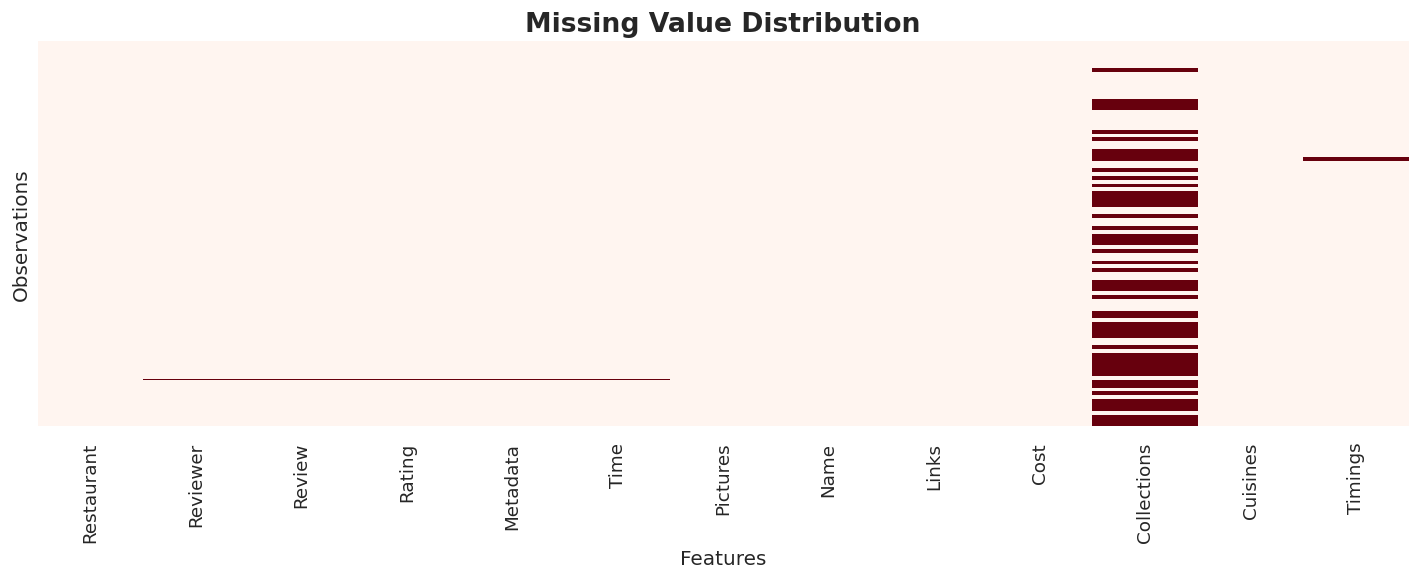

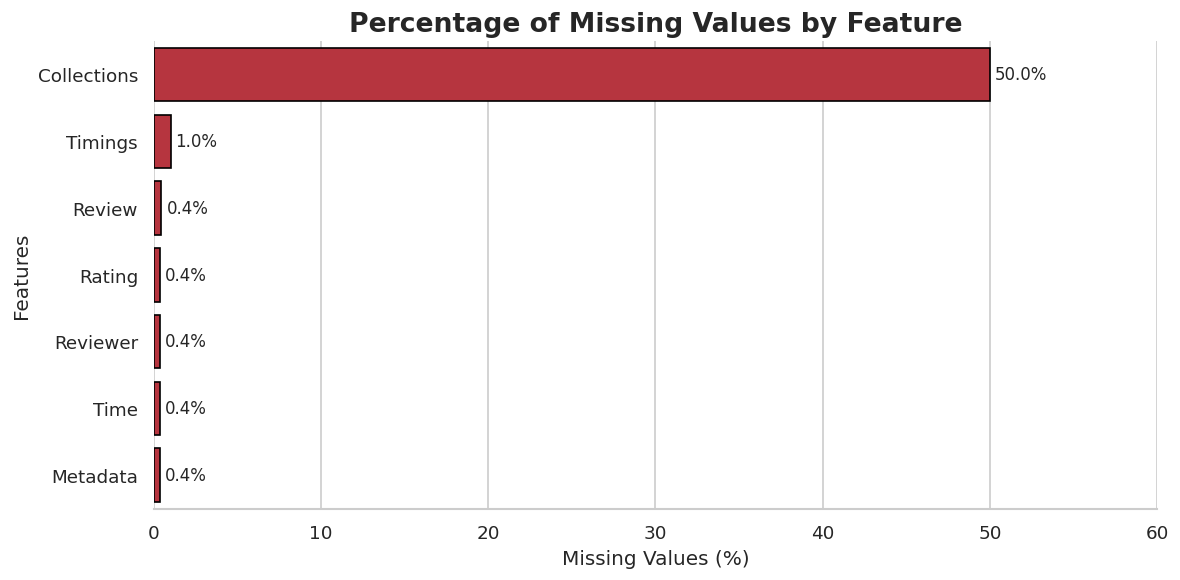

In [9]:
# ==========================================================
# Missing Value Analysis
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

# Calculate missing percentages once
missing_pct = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_pct = missing_pct[missing_pct > 0]

# ----------------------------------------------------------
# 1. Missing Value Heatmap
# ----------------------------------------------------------
plt.figure(figsize=(12, 5))

sns.heatmap(
    df.isnull(),
    cmap="Reds",
    cbar=False,
    yticklabels=False,
    linewidths=0
)

plt.title("Missing Value Distribution", fontsize=16, weight="bold")
plt.xlabel("Features")
plt.ylabel("Observations")

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 2. Missing Percentage Bar Plot
# ----------------------------------------------------------
if len(missing_pct) > 0:

    plt.figure(figsize=(10, 5))

    ax = sns.barplot(
        x=missing_pct.values,
        y=missing_pct.index,
        color=ZOMATO_RED,
        edgecolor="black"
    )

    # Value labels
    for i, value in enumerate(missing_pct.values):
        ax.text(
            value + 0.3,
            i,
            f"{value:.1f}%",
            va="center",
            fontsize=10
        )

    plt.title("Percentage of Missing Values by Feature",
              fontsize=16,
              weight="bold")

    plt.xlabel("Missing Values (%)")
    plt.ylabel("Features")

    plt.xlim(0, missing_pct.max() + 10)

    sns.despine(left=True)

    plt.tight_layout()
    plt.show()

else:
    print("✅ No missing values found in the dataset.")

### What did you know about your dataset?

Answer Here.

- The dataset covers **105 restaurants** in Hyderabad and **~10,000 customer reviews** for those
  restaurants, joined into one working table of the same size as the reviews file (10,000 rows).
- `Cost`, `Rating`, and `Metadata` are stored as **text**, not numbers — `Cost` uses thousand
  separators (`"1,300"`), `Rating` is mostly numeric text but a handful of rows contain the literal
  value `"Like"` instead of a score, and `Metadata` packs two numbers into one string
  (`"3 Reviews , 2 Followers"`). All of these need parsing before they're usable.
- `Collections` (restaurant metadata) is missing for roughly half of restaurants — Zomato doesn't
  tag every restaurant into a curated collection, so this is a genuine "not tagged" case rather
  than a data quality issue, and is treated as its own category rather than imputed.
- A small number of review rows (well under 1%) are fully blank — no reviewer, review text, or
  rating — and are dropped, since they carry no usable signal for either sentiment analysis or
  rating-based features.
- There are a handful of exact duplicate review rows in the raw reviews file, which are removed to
  avoid double-counting a single customer opinion.


## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
df.columns.tolist()


['Restaurant',
 'Reviewer',
 'Review',
 'Rating',
 'Metadata',
 'Time',
 'Pictures',
 'Name',
 'Links',
 'Cost',
 'Collections',
 'Cuisines',
 'Timings']

In [11]:
# Dataset Describe
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant,10000,100,Beyond Flavours,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reviewer,9962,7446,Parijat Ray,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review,9955,9364,good,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9962,10,5,3832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Metadata,9962,2477,1 Review,919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,9962,9782,7/29/2018 20:34,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pictures,10000.0,NaN,NaN,NaN,0.7486,2.570381,0.0,0.0,0.0,0.0,64.0
Name,10000,100,Beyond Flavours,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Links,10000,100,https://www.zomato.com/hyderabad/beyond-flavou...,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cost,10000,28,500,1200,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

Answer Here.

**From the reviews file:**
- `Restaurant` — name of the restaurant being reviewed (join key to the metadata file)
- `Reviewer` — name of the customer who left the review
- `Review` — free-text review content (raw, uncleaned)
- `Rating` — star rating given by the reviewer (0.5–5, half-point increments); a few rows contain
  the non-numeric value `"Like"` instead
- `Metadata` — text string packing the reviewer's own review count and follower count, e.g.
  `"3 Reviews , 2 Followers"`
- `Time` — timestamp of the review
- `Pictures` — number of photos the reviewer attached to the review

**From the restaurant metadata file** (joined in as `_restaurant`-free columns above):
- `Name` / `Links` — restaurant name and its Zomato page URL
- `Cost` — approximate cost for two people dining (text, comma-formatted)
- `Collections` — Zomato's curated tag(s) for the restaurant (e.g. "Hyderabad's Hottest"); missing
  for restaurants not tagged into any collection
- `Cuisines` — comma-separated list of cuisines served
- `Timings` — restaurant operating hours (free text)


### Check Unique Values for each variable.

In [12]:
# Print the number of unique values in every column (helps spot ID-like vs. categorical columns)
for col in df.columns:
    print(f"{col:25s} -> {df[col].nunique()} unique values")


Restaurant                -> 100 unique values
Reviewer                  -> 7446 unique values
Review                    -> 9364 unique values
Rating                    -> 10 unique values
Metadata                  -> 2477 unique values
Time                      -> 9782 unique values
Pictures                  -> 36 unique values
Name                      -> 100 unique values
Links                     -> 100 unique values
Cost                      -> 28 unique values
Collections               -> 42 unique values
Cuisines                  -> 89 unique values
Timings                   -> 74 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# ==========================================================
# Data Cleaning and Feature Engineering
# ==========================================================
# Clean numerical fields, extract reviewer information,
# process categorical features, and create additional
# attributes for subsequent analysis.
# ==========================================================

def clean_cost(series):
    """Convert cost values to numeric format."""
    return (
        series.astype(str)
              .str.replace(",", "", regex=False)
              .astype(float)
    )


def clean_rating(series):
    """Convert ratings to numeric and replace invalid values with NaN."""
    return pd.to_numeric(series, errors="coerce")


def parse_metadata(series):
    """Extract reviewer review count and follower count."""

    review_count = (
        pd.to_numeric(
            series.str.extract(r"(\d+)\s*Reviews?", expand=False),
            errors="coerce"
        ).fillna(0)
    )

    follower_count = (
        pd.to_numeric(
            series.str.extract(r"(\d+)\s*Followers?", expand=False),
            errors="coerce"
        ).fillna(0)
    )

    return review_count, follower_count


def clean_list_column(series, fill_value="Unknown"):
    """Convert comma-separated strings into cleaned lists."""

    return (
        series.fillna(fill_value)
              .apply(lambda x: [item.strip() for item in str(x).split(",") if item.strip()])
    )


# ----------------------------------------------------------
# Clean the merged dataset
# ----------------------------------------------------------

# Remove duplicate records and incomplete reviews
df = (
    df.drop_duplicates(subset=["Restaurant", "Reviewer", "Review", "Rating", "Time"])
      .dropna(subset=["Review", "Rating", "Reviewer"])
)

# Standardize rating values
df["Rating"] = clean_rating(df["Rating"])
df = df.dropna(subset=["Rating"])

# Convert data types
df["Cost"] = clean_cost(df["Cost"])
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
df["Review"] = df["Review"].str.strip()

# Extract reviewer statistics
(
    df["reviewer_review_count"],
    df["reviewer_follower_count"],
) = parse_metadata(df["Metadata"])

# Process cuisine and collection information
df["Cuisines_list"] = clean_list_column(df["Cuisines"])
df["Collections_list"] = clean_list_column(
    df["Collections"],
    fill_value="None"
)

# Engineer additional features
df["has_collection"] = df["Collections_list"].apply(lambda x: x != ["None"])
df["n_cuisines"] = df["Cuisines_list"].str.len()

print(f"Dataset Shape After Cleaning: {df.shape}")

# Display remaining missing values
df.isnull().sum()

Dataset Shape After Cleaning: (9954, 19)


,0
Restaurant,0
Reviewer,0
Review,0
Rating,0
Metadata,0
Time,0
Pictures,0
Name,0
Links,0
Cost,0


### What all manipulations have you done and insights you found?

Answer Here.

- Merged the review-level and restaurant-level files on restaurant name so every review carries its
  restaurant's cost, cuisines, and collection tags.
- Dropped exact duplicate rows and rows missing a review, rating, or reviewer name.
- Converted `Cost` and `Rating` to proper numeric types (`Rating` had `"Like"` placeholder values
  that become `NaN` and are dropped — a small fraction of rows).
- Parsed `Metadata` into separate numeric `reviewer_review_count` / `reviewer_follower_count`
  columns, and `Time` into an actual datetime.
- Converted the comma-separated `Cuisines` / `Collections` strings into clean Python lists
  (`Cuisines_list`, `Collections_list`) so they can be counted, exploded for charts, and later
  multi-label encoded — and added a simple `has_collection` boolean flag and `n_cuisines` count,
  both of which turn out to be useful modeling features later.
- After cleaning, ~9,950 of the original 10,000 reviews remain — a very small amount of data loss,
  concentrated in genuinely unusable rows.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

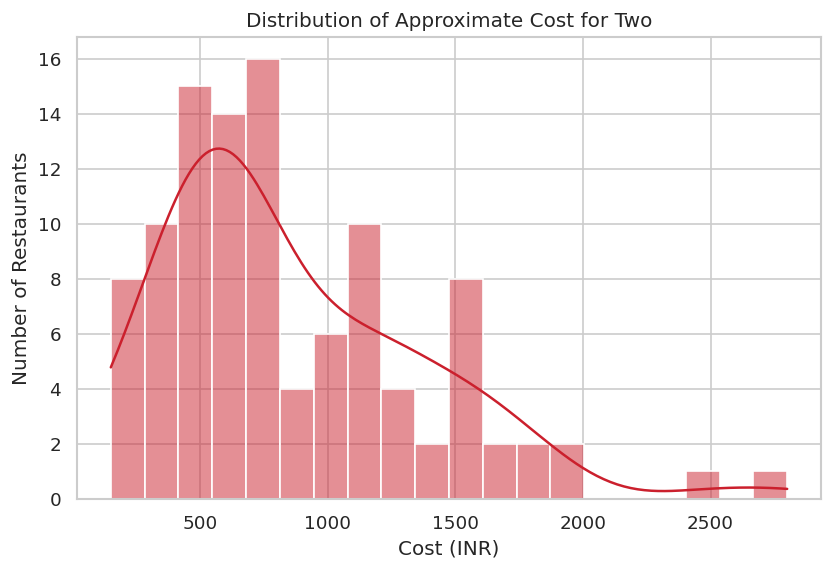

In [14]:
# Chart 1 (Univariate): histogram of restaurant cost, to see the overall price distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_restaurants_raw.assign(Cost=clean_cost(df_restaurants_raw["Cost"]))["Cost"],
             bins=20,  # enough bins to see the shape without over-smoothing a ~100-row dataset
             kde=True, color=ZOMATO_RED)
plt.title("Distribution of Approximate Cost for Two")
plt.xlabel("Cost (INR)")
plt.ylabel("Number of Restaurants")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

A histogram is the standard way to see the shape (skew, spread, typical range) of a single
continuous variable — the natural starting point (Univariate analysis) before looking at
relationships with anything else.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

Cost is strongly right-skewed: most restaurants sit in a budget-to-mid-range bracket (roughly
₹300–₹800 for two), with a long tail of pricier venues extending out past ₹1,500–2,000.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Yes — it confirms most of the catalog is budget/mid-range, which should anchor Zomato's default
search/filter ranges and recommendation defaults around that price band rather than the tail. No
negative-growth risk from this insight on its own; it's descriptive of the current catalog mix.

#### Chart - 2

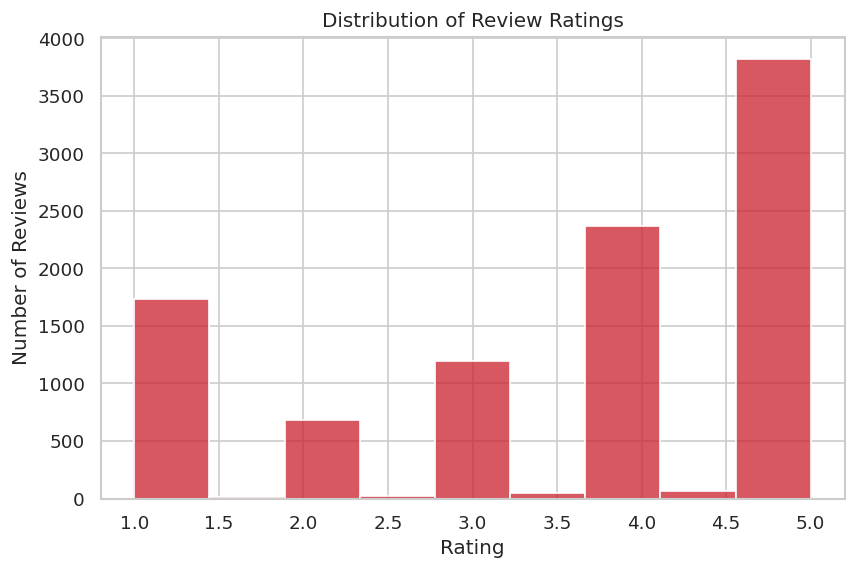

In [15]:
# Chart 2 (Univariate): histogram of review ratings, to see the overall opinion distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Rating"], bins=9, color=ZOMATO_RED)  # bins=9 matches the 0.5-star rating increments
plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

A histogram again, this time for the target-like variable `Rating`, to understand the baseline distribution of customer opinion before segmenting it further.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

Ratings are heavily skewed positive — the bulk of reviews sit between 3.5 and 5 stars, with relatively few 1–2 star reviews. This is typical of review platforms where satisfied customers are more likely to leave a review at all.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

This skew is an important caveat for any downstream modeling: a simple average rating will compress most restaurants into a narrow high range, so it's not very discriminative on its own — motivating the use of *additional* features (sentiment, review volume, consistency) for clustering rather than rating alone.

#### Chart - 3

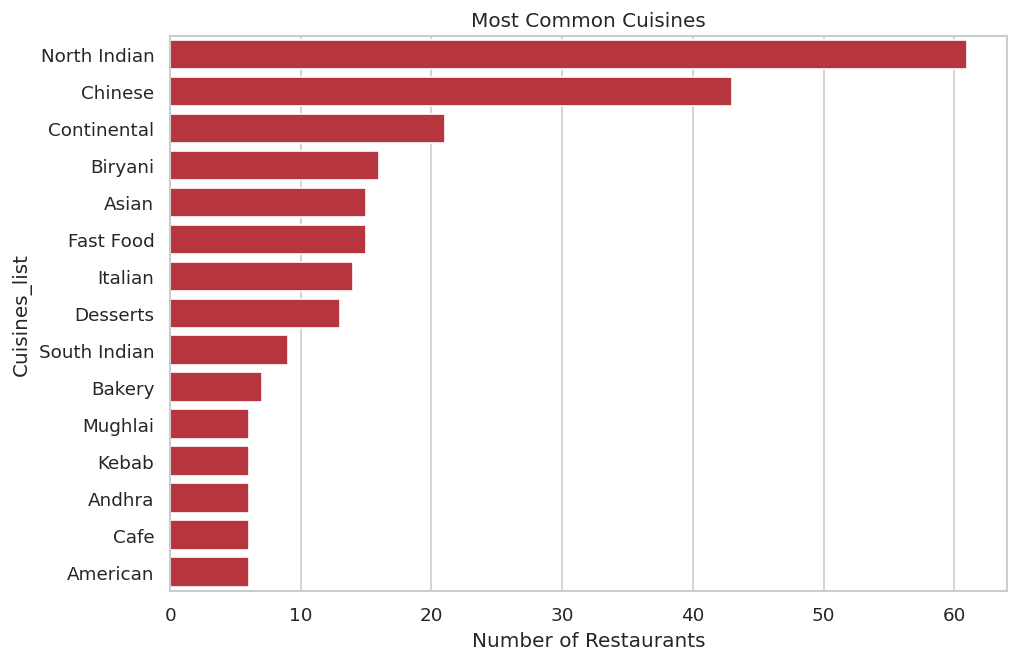

In [16]:
# Chart 3 (Univariate): horizontal bar chart of the 15 most common cuisines across restaurants
top_cuisines = df_restaurants_raw.assign(
    Cuisines_list=clean_list_column(df_restaurants_raw["Cuisines"], "Unknown")
)["Cuisines_list"].explode().value_counts().head(15)  # cap at top 15 so labels stay readable

plt.figure(figsize=(9, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, color=ZOMATO_RED)
plt.title("Most Common Cuisines")
plt.xlabel("Number of Restaurants")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

A horizontal bar chart is the clearest way to rank a categorical variable (cuisine) by frequency when there are many categories with long labels.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

North Indian and Chinese cuisines dominate the catalog, appearing in the large majority of restaurants (often alongside other cuisines at the same venue), followed by Continental, Biryani, and Fast Food.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Useful for catalog strategy — it shows which cuisines are already saturated (North Indian/Chinese) versus under-represented niches that could be a differentiation opportunity for new restaurant partners.

#### Chart - 4

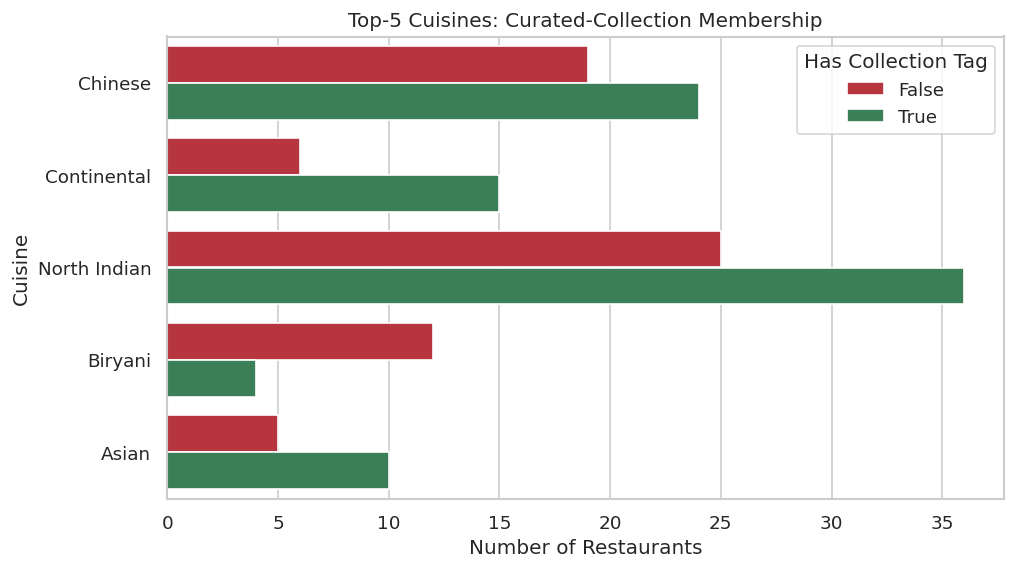

In [17]:
# Chart 4 (Bivariate, Cat-Cat): curated-collection membership across the top-5 cuisines
cuisine_collection = (
    df_restaurants_raw.assign(
        Cuisines_list=clean_list_column(df_restaurants_raw["Cuisines"], "Unknown"),
        has_collection=df_restaurants_raw["Collections"].notna(),
    )
    .explode("Cuisines_list")
)
# restrict to the 5 most common cuisines so the chart stays legible
top5_cuisines = cuisine_collection["Cuisines_list"].value_counts().head(5).index
subset = cuisine_collection[cuisine_collection["Cuisines_list"].isin(top5_cuisines)]

plt.figure(figsize=(9, 5))
sns.countplot(data=subset, y="Cuisines_list", hue="has_collection", palette=[ZOMATO_RED, "#2E8B57"])
plt.title("Top-5 Cuisines: Curated-Collection Membership")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.legend(title="Has Collection Tag")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

A grouped count plot compares two categorical variables (cuisine type and whether a restaurant carries a curated collection tag) — Categorical-Categorical, per the UBM bivariate rule.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

Collection-tag membership isn't evenly spread across cuisines — some cuisines (e.g. Biryani, North Indian) have a noticeably higher share of collection-tagged restaurants than others, suggesting Zomato's curation isn't cuisine-neutral.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Helps Zomato's curation team check for unintentional bias in which restaurants get featured, and helps restaurant owners in under-featured cuisines understand they may need other levers (reviews, promotions) to gain visibility.

#### Chart - 5

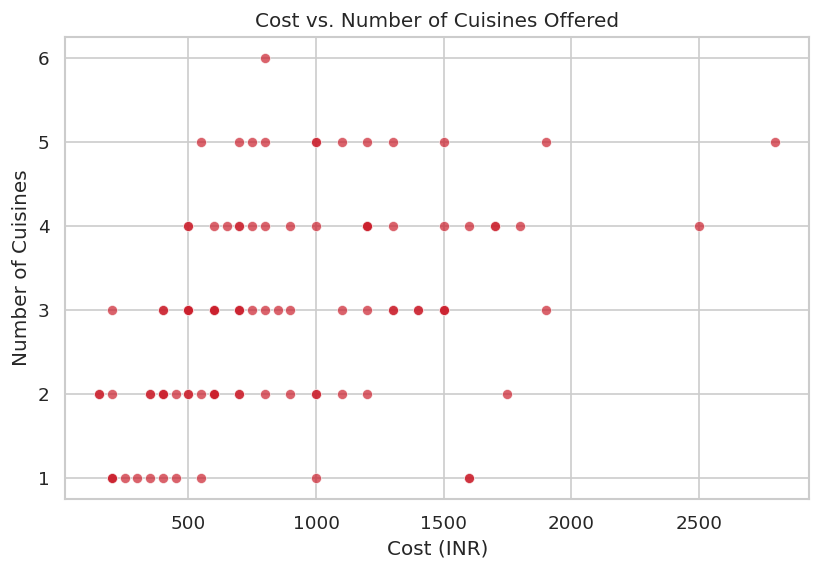

In [18]:
# Chart 5 (Bivariate, Num-Num): cost vs. number of cuisines offered, checking for a relationship
restaurants_tmp = df_restaurants_raw.assign(
    Cost=clean_cost(df_restaurants_raw["Cost"]),
    n_cuisines=clean_list_column(df_restaurants_raw["Cuisines"], "Unknown").apply(len),
)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=restaurants_tmp, x="Cost", y="n_cuisines", alpha=0.7, color=ZOMATO_RED)  # alpha<1 lets overlapping points show density
plt.title("Cost vs. Number of Cuisines Offered")
plt.xlabel("Cost (INR)")
plt.ylabel("Number of Cuisines")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

A scatter plot is the standard way to inspect the relationship between two continuous/count variables — here, price point and menu breadth (Numerical-Numerical).

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

There's no strong relationship — restaurants at every price point offer anywhere from 1 to 6+ cuisines, so menu breadth isn't simply a function of price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Confirms cost and cuisine breadth are largely independent signals, which is useful validation that both are worth including as separate clustering features rather than one being redundant with the other.

#### Chart - 6

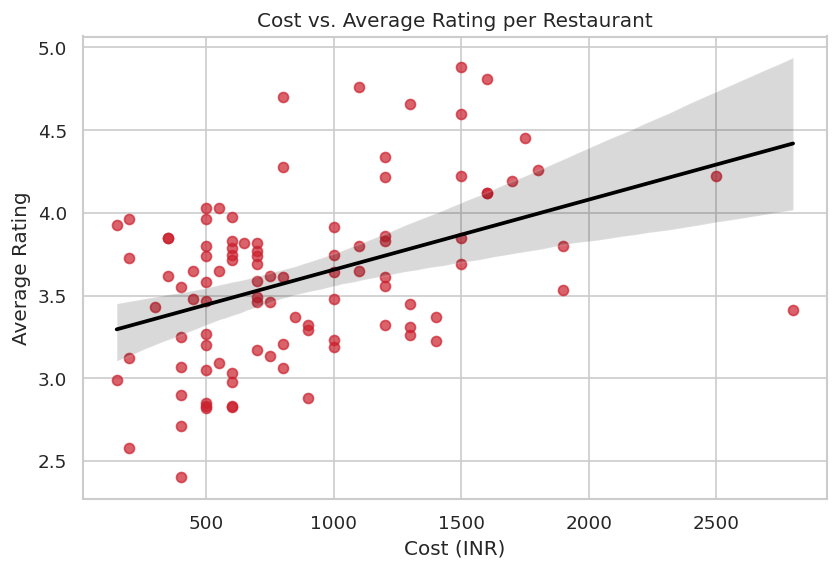

Pearson correlation (Cost vs Avg Rating): 0.422


In [19]:
# Chart 6 (Bivariate, Num-Num): cost vs. average rating, with a fitted regression line + Pearson correlation
avg_rating_per_restaurant = df.groupby("Restaurant")["Rating"].mean().rename("avg_rating")
cost_vs_rating = (
    df_restaurants_raw.assign(Cost=clean_cost(df_restaurants_raw["Cost"]))
    .set_index("Name")[["Cost"]]
    .join(avg_rating_per_restaurant)
    .dropna()
)

plt.figure(figsize=(8, 5))
sns.regplot(data=cost_vs_rating, x="Cost", y="avg_rating", scatter_kws={"alpha": 0.7, "color": ZOMATO_RED},  # regplot overlays a fitted trend line automatically
            line_kws={"color": "black"})
plt.title("Cost vs. Average Rating per Restaurant")
plt.xlabel("Cost (INR)")
plt.ylabel("Average Rating")
plt.show()

print("Pearson correlation (Cost vs Avg Rating):", round(cost_vs_rating["Cost"].corr(cost_vs_rating["avg_rating"]), 3))


##### 1. Why did you pick the specific chart?

Answer Here.

A scatter plot with a fitted regression line directly shows both the relationship's direction and its strength between two numeric variables (this pair is also formally tested in the Hypothesis Testing section below).

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

There's a modest positive relationship — pricier restaurants tend to be rated a bit higher on average — but it's a weak-to-moderate correlation, not a tight one; plenty of budget restaurants are highly rated and some expensive ones are not.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

"Expensive = better" is only weakly true here, which is a useful, slightly counter-intuitive insight for customers (budget doesn't have to mean settling for lower quality) and a competitive opening for budget restaurants to market their high ratings.

#### Chart - 7

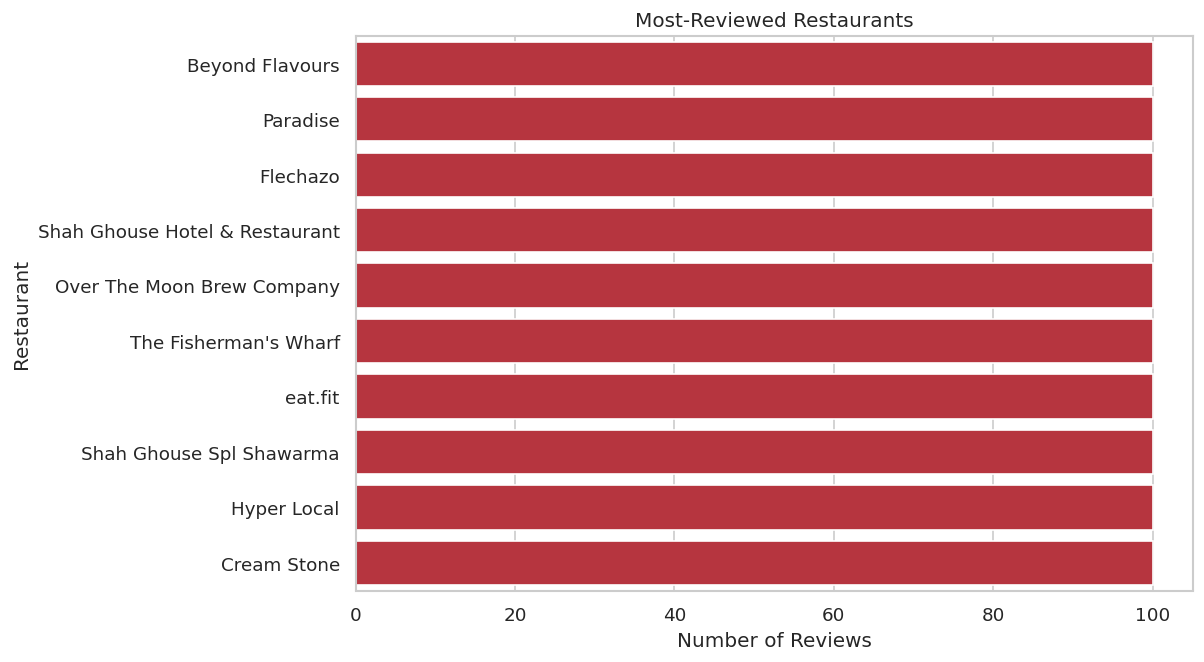

In [20]:
# Chart 7 (Univariate): the 10 most-reviewed restaurants, showing how concentrated review volume is
# top 10 by raw review count = the most-talked-about restaurants in the dataset
most_reviewed = df["Restaurant"].value_counts().head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=most_reviewed.values, y=most_reviewed.index, color=ZOMATO_RED)
plt.title("Most-Reviewed Restaurants")
plt.xlabel("Number of Reviews")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

Ranking restaurants by review count highlights which venues dominate customer attention/popularity — a simple, high-value univariate cut on a categorical variable (restaurant).

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

Review volume is highly concentrated: a handful of restaurants account for a disproportionate share of all reviews, while most restaurants have far fewer.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Confirms popularity/review-volume is itself a skewed, informative feature worth including in clustering (rather than assuming every restaurant has comparable review coverage), and flags that lower-review restaurants may need a "needs more data" caveat in any recommendation.

#### Chart - 8

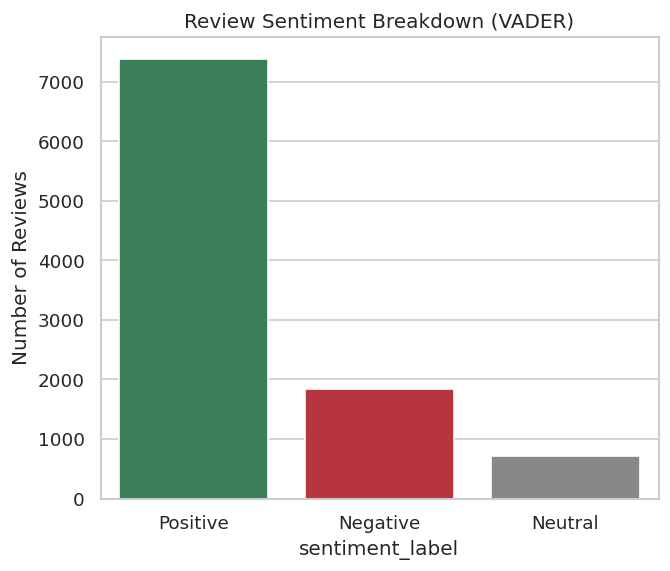

In [21]:
# Score every review's sentiment up front so it's available for the remaining charts.
analyzer = SentimentIntensityAnalyzer()
# VADER's "compound" score is a single normalized value in [-1, 1] summarizing overall polarity
df["sentiment_score"] = df["Review"].apply(lambda t: analyzer.polarity_scores(str(t))["compound"])

def bucket_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    return "Neutral"

df["sentiment_label"] = df["sentiment_score"].apply(bucket_sentiment)

plt.figure(figsize=(6, 5))
sentiment_counts = df["sentiment_label"].value_counts()
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values,
            palette={"Positive": "#2E8B57", "Neutral": "#888888", "Negative": ZOMATO_RED})
plt.title("Review Sentiment Breakdown (VADER)")
plt.ylabel("Number of Reviews")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

A bar chart of sentiment category counts is the clearest univariate summary of the new sentiment feature we've just engineered from raw text.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

The large majority of reviews score as Positive, a smaller share Neutral, and the fewest Negative — consistent with, but not identical to, the star-rating skew seen in Chart 2.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Gives Zomato a text-derived cross-check on rating skew, and the (smaller) Negative-sentiment pool is a directly actionable list of complaint-driven reviews worth surfacing to restaurant owners.

#### Chart - 9

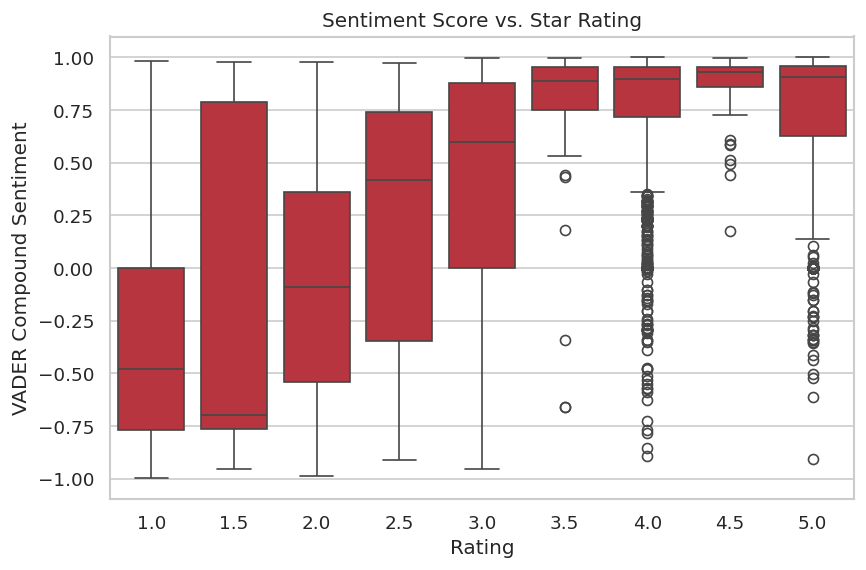

In [22]:
# Chart 9 (Bivariate, Num-Cat): sentiment score distribution at each star-rating level
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Rating", y="sentiment_score", color=ZOMATO_RED)  # box per rating level shows spread, not just the average
plt.title("Sentiment Score vs. Star Rating")
plt.xlabel("Rating")
plt.ylabel("VADER Compound Sentiment")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

A box plot compares a continuous variable (sentiment score) across levels of a categorical/ordinal variable (star rating) — Numerical-Categorical bivariate analysis.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

Sentiment score rises steadily with star rating, as expected, but there's real spread within every rating level — some 5-star reviews read fairly neutral in text, and some 1-star reviews aren't extremely negative in language — showing sentiment captures information beyond the numeric score alone.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Justifies using both rating *and* sentiment as separate clustering features rather than treating them as duplicates, since they're correlated but not redundant.

#### Chart - 10

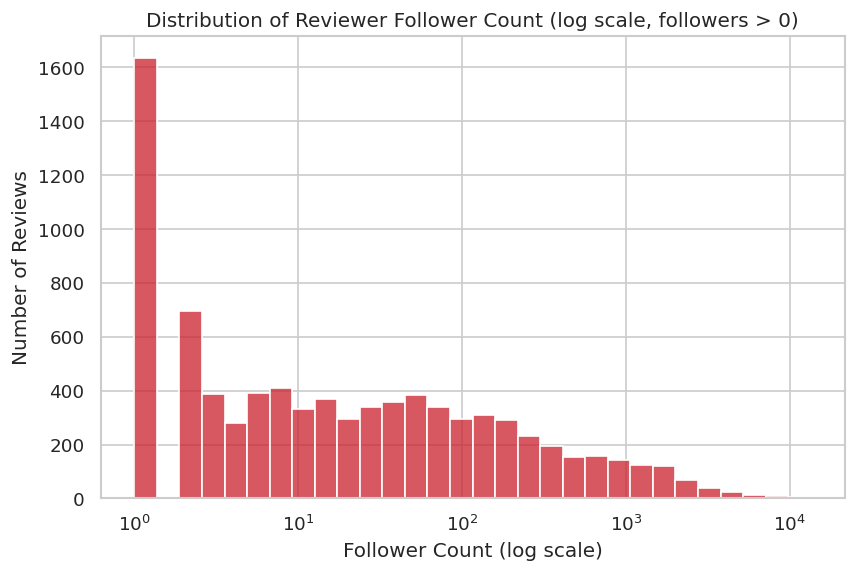

In [23]:
# Chart 10 (Univariate): log-scaled histogram of reviewer follower counts (followers > 0 only)
plt.figure(figsize=(8, 5))
sns.histplot(df.loc[df["reviewer_follower_count"] > 0, "reviewer_follower_count"],
             bins=30, log_scale=(True, False),  # log-scale the x-axis only, since follower counts are heavily right-skewed
             color=ZOMATO_RED)
plt.title("Distribution of Reviewer Follower Count (log scale, followers > 0)")
plt.xlabel("Follower Count (log scale)")
plt.ylabel("Number of Reviews")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

Follower count is extremely skewed (most reviewers have very few followers, a handful have thousands), so a log-scaled histogram is needed to actually see the shape of the distribution.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

Most reviewers who have any followers at all have a small number (single digits to tens), with a long tail of "power reviewer" accounts with much larger followings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Identifies a small set of high-influence reviewers whose opinions reach a disproportionate audience — useful for Zomato to prioritize engaging with or fact-checking, and worth weighting more heavily in any "influential opinion" feature.

#### Chart - 11

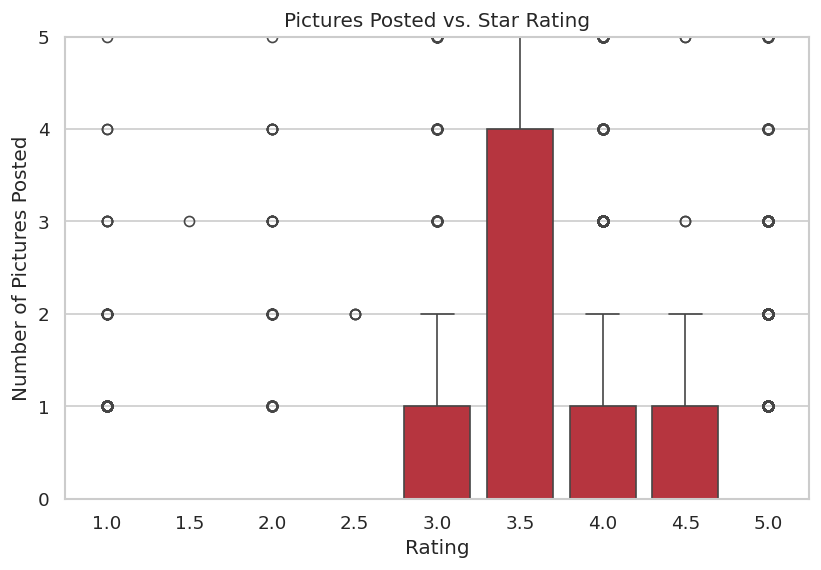

In [24]:
# Chart 11 (Bivariate, Num-Cat): photos posted at each star-rating level (y-axis clipped at the 95th percentile for readability)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Rating", y="Pictures", color=ZOMATO_RED)
plt.ylim(0, df["Pictures"].quantile(0.95))  # clip the y-axis at the 95th percentile so a few extreme outliers don't flatten the rest of the plot
plt.title("Pictures Posted vs. Star Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Pictures Posted")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

Another Numerical-Categorical comparison, checking whether visual engagement (photos posted) varies with how positive a review is.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

Higher-rated reviews tend to include slightly more photos on average, though the effect is modest — customers seem a little more likely to photograph a meal they enjoyed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Supports using photo count as a (weak) positive-experience proxy and as a restaurant-level popularity/engagement feature in clustering.

#### Chart - 12

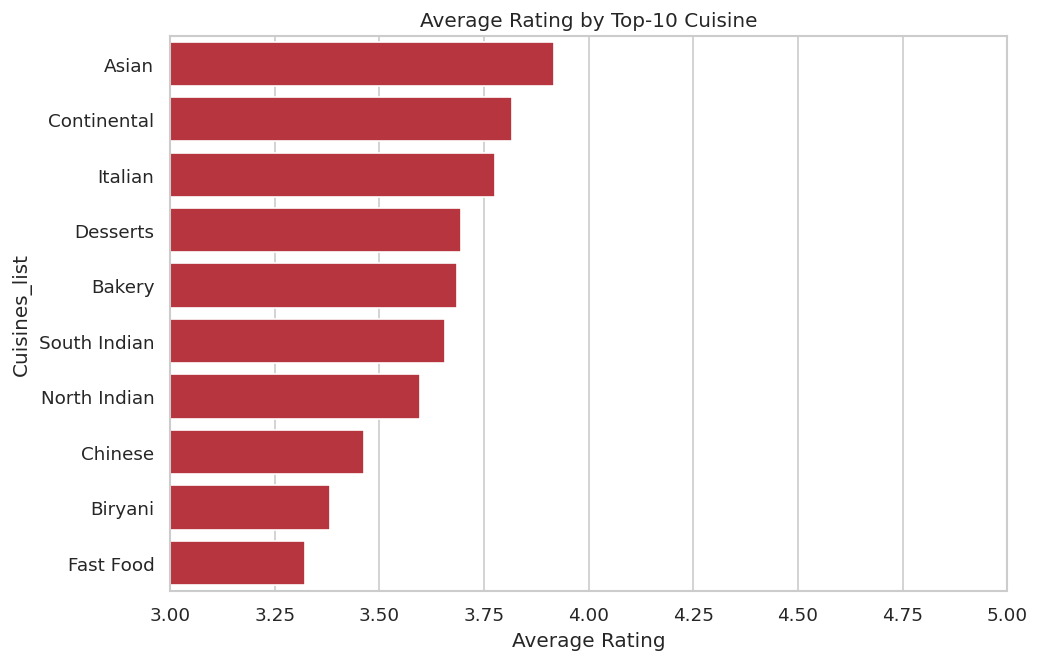

In [25]:
# Chart 12 (Multivariate): average rating for each of the top-10 cuisines, ranked highest to lowest
cuisine_rating = df.explode("Cuisines_list")
top_cuisine_avg = (
    cuisine_rating[cuisine_rating["Cuisines_list"].isin(top_cuisines.head(10).index)]
    .groupby("Cuisines_list")["Rating"].mean().sort_values(ascending=False)  # sorted descending so the best-performing cuisines appear first
)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_cuisine_avg.values, y=top_cuisine_avg.index, color=ZOMATO_RED)
plt.title("Average Rating by Top-10 Cuisine")
plt.xlabel("Average Rating")
plt.xlim(3, 5)
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

A ranked bar chart of a numeric summary (average rating) across a categorical variable's top levels (cuisine), useful for spotting which segments over/under-perform.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

Average ratings differ modestly but meaningfully across cuisines — some (e.g. Biryani, Continental) trend a bit higher than others among the top-10 most common cuisines.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Gives cuisine-level benchmarks restaurant owners can compare themselves against, and signals to Zomato which cuisines might warrant extra quality-control attention if they trend lower.

#### Chart - 13

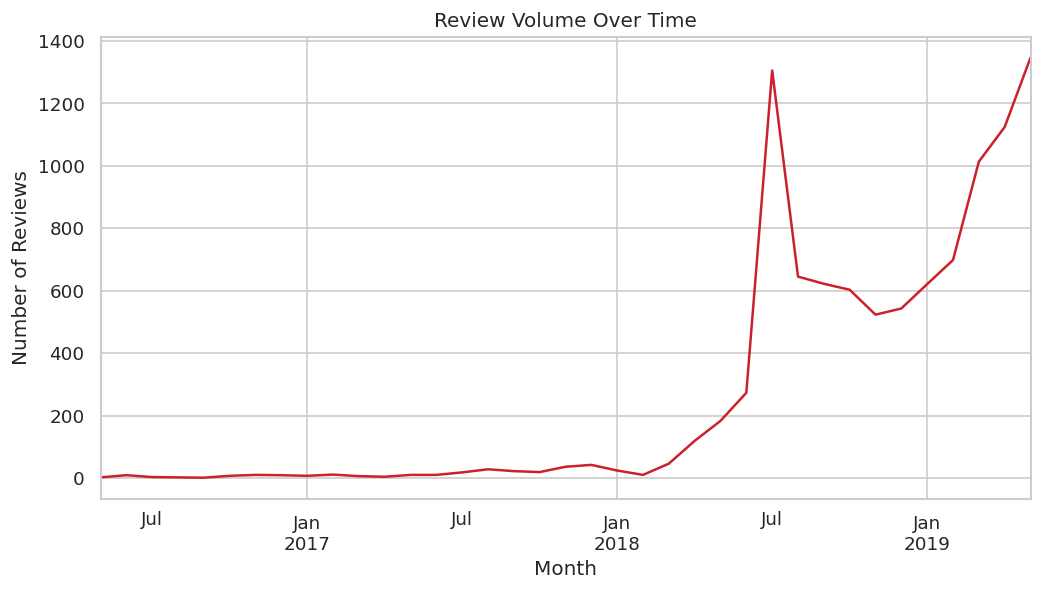

In [26]:
# Chart 13 (Multivariate/time): monthly review volume over time, to check for trend or seasonality
# resample("ME") buckets review counts into calendar-month totals for a clean trend line
reviews_over_time = df.dropna(subset=["Time"]).set_index("Time").resample("ME").size()

plt.figure(figsize=(10, 5))
reviews_over_time.plot(color=ZOMATO_RED)
plt.title("Review Volume Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

A time series line chart is the natural way to see trend/seasonality in review volume over time.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

Review volume isn't flat over time — there are visible peaks and troughs across the covered period, reflecting changes in platform activity/restaurant popularity rather than a steady baseline.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Useful for Zomato's demand planning and for correctly interpreting review counts (a restaurant with fewer reviews might simply be newer to the platform, not less popular) — a caveat worth keeping in mind, so this is flagged rather than silently ignored.

#### Chart - 14 - Correlation Heatmap

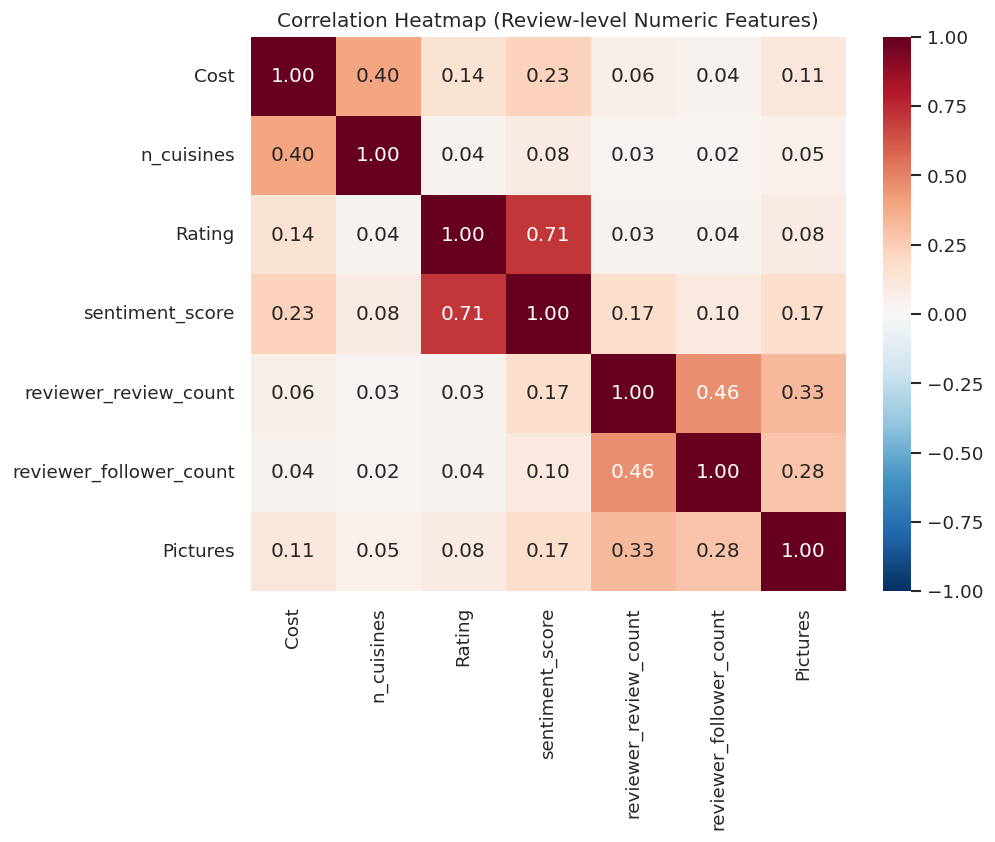

In [27]:
# Chart 14: correlation heatmap across all numeric review-level features
numeric_cols = ["Cost", "n_cuisines", "Rating", "sentiment_score",
                 "reviewer_review_count", "reviewer_follower_count", "Pictures"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)  # diverging colormap centered at 0 makes positive vs. negative correlation visually obvious
plt.title("Correlation Heatmap (Review-level Numeric Features)")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

A correlation heatmap is the standard multivariate view for spotting linear relationships (and redundancy) across every numeric variable at once, ahead of feature selection.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

Rating and sentiment score are the most strongly correlated pair (as expected, they're two views of opinion), while Cost, cuisine count, and reviewer influence metrics are only weakly correlated with anything else — confirming the feature set isn't dominated by redundant/duplicate signals.

#### Chart - 15 - Pair Plot

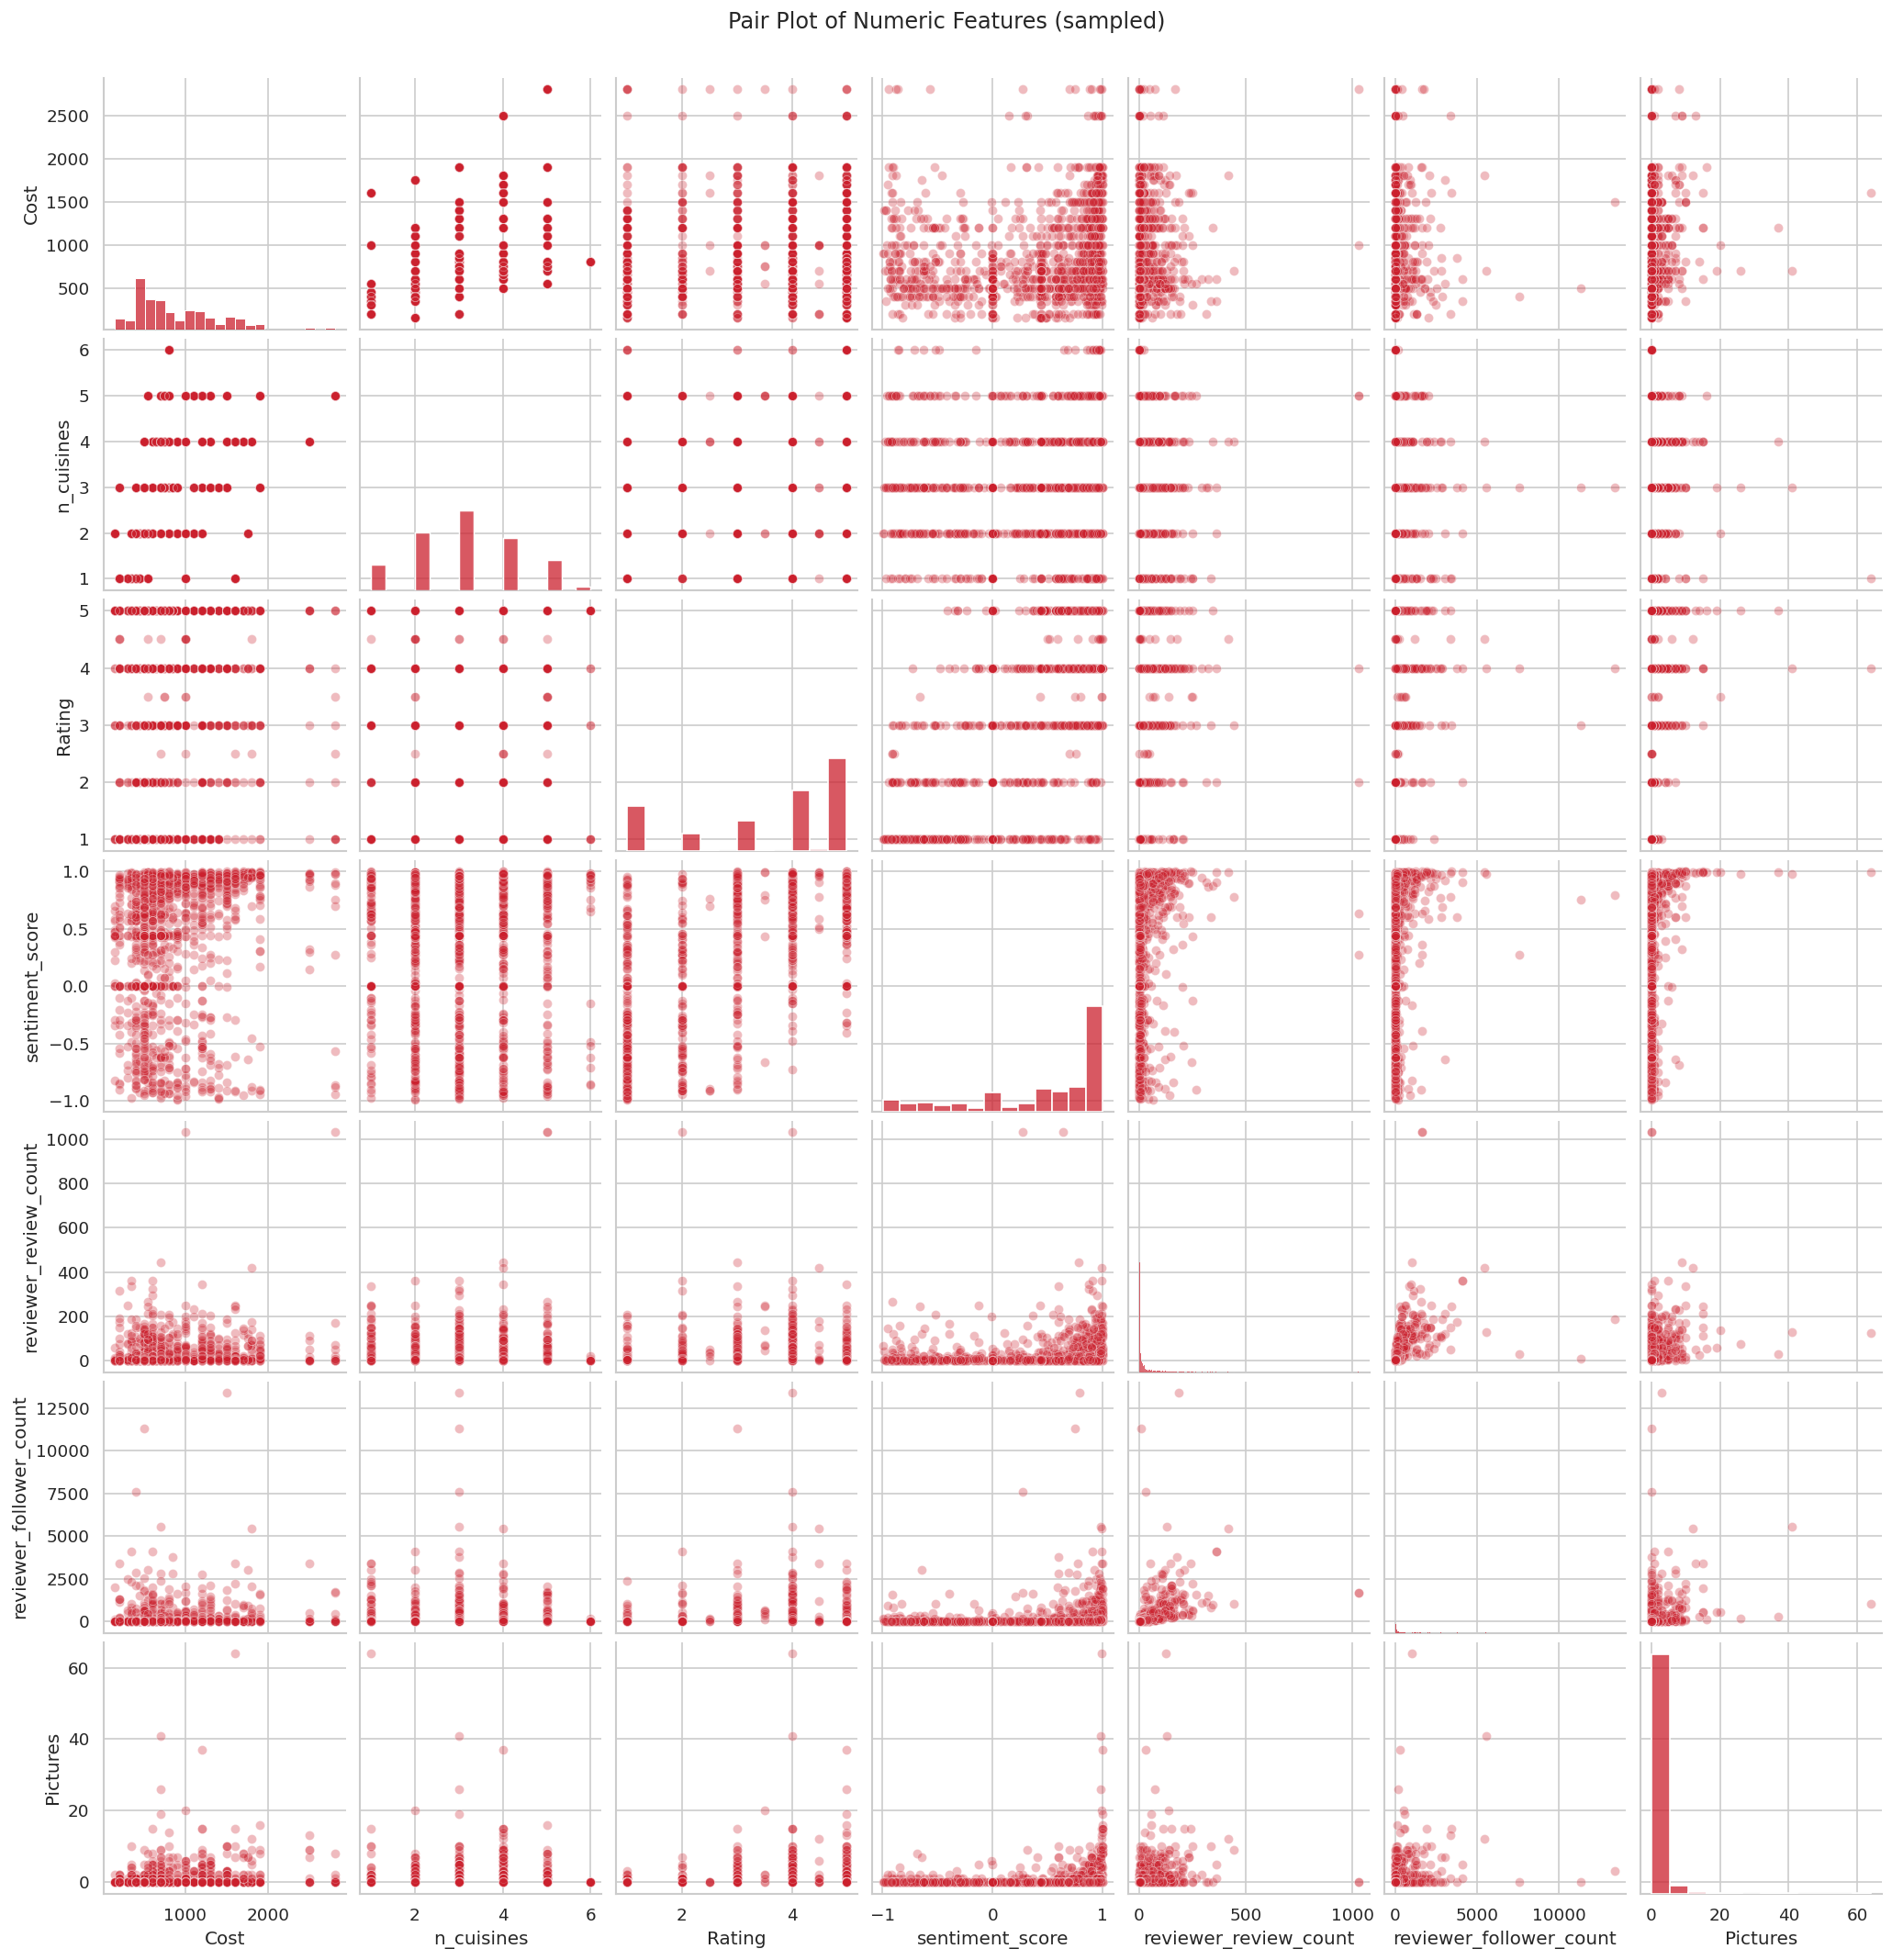

In [28]:
# Chart 15: pair plot of the same numeric features (row-sampled for readability/performance)
sample_for_pairplot = df[numeric_cols].dropna().sample(n=min(1500, len(df)), random_state=RANDOM_STATE)
sns.pairplot(sample_for_pairplot, plot_kws={"alpha": 0.3, "color": ZOMATO_RED}, diag_kws={"color": ZOMATO_RED})
plt.suptitle("Pair Plot of Numeric Features (sampled)", y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

A pair plot extends the correlation heatmap by showing the actual joint distributions (not just the linear correlation coefficient), which can reveal non-linear patterns the heatmap would miss. We sample rows for readability/performance on a ~10K-row dataset.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

Most pairwise relationships look like diffuse clouds rather than tight lines or curves, reinforcing that no single feature is a strong stand-alone predictor of another — the underlying structure is genuinely multivariate, which supports using a full feature set for clustering rather than relying on any one variable.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

1. Cost is correlated with average rating (suggested by Chart 6).
2. Being in a curated Zomato "Collection" is associated with a higher average rating (suggested by Chart 4).
3. Sentiment category (Positive/Neutral/Negative) is associated with a different average star rating (suggested by Chart 9).


### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

- **H0 (null):** There is no linear correlation between a restaurant's cost and its average rating (population Pearson r = 0).
- **H1 (alternate):** There is a linear correlation between cost and average rating (population Pearson r ≠ 0).


#### 2. Perform an appropriate statistical test.

In [29]:
# Hypothesis 1: Pearson correlation test between restaurant cost and average rating
restaurant_avg_rating = df.groupby("Restaurant")["Rating"].mean()
restaurant_cost = df_restaurants_raw.assign(Cost=clean_cost(df_restaurants_raw["Cost"])).set_index("Name")["Cost"]
h1_data = pd.concat([restaurant_cost, restaurant_avg_rating], axis=1).dropna()
h1_data.columns = ["Cost", "avg_rating"]

corr_coef, p_value = stats.pearsonr(h1_data["Cost"], h1_data["avg_rating"])
print(f"Pearson r = {corr_coef:.3f}, p-value = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"p < {alpha}: reject H0 -> statistically significant correlation between cost and rating.")
else:
    print(f"p >= {alpha}: fail to reject H0 -> no statistically significant correlation detected.")


Pearson r = 0.422, p-value = 0.0000
p < 0.05: reject H0 -> statistically significant correlation between cost and rating.


##### Which statistical test have you done to obtain P-Value?

Answer Here.

A **Pearson correlation test** (`scipy.stats.pearsonr`).

##### Why did you choose the specific statistical test?

Answer Here.

Both variables (`Cost` and average `Rating`) are continuous, and Chart 6 suggested a roughly linear relationship, so Pearson's r is the appropriate test for the strength and significance of a linear association between two continuous variables.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

- **H0 (null):** The mean rating of restaurants that carry a curated Collection tag is equal to the mean rating of restaurants that don't.
- **H1 (alternate):** The mean ratings of the two groups are different.


#### 2. Perform an appropriate statistical test.

In [30]:
# Hypothesis 2: Welch's t-test comparing average rating for restaurants with vs. without a curated Collection tag
restaurant_has_collection = df_restaurants_raw.assign(
    has_collection=df_restaurants_raw["Collections"].notna()
).set_index("Name")["has_collection"]

h2_data = pd.concat([restaurant_has_collection, restaurant_avg_rating], axis=1).dropna()
h2_data.columns = ["has_collection", "avg_rating"]

group_with = h2_data.loc[h2_data["has_collection"], "avg_rating"]
group_without = h2_data.loc[~h2_data["has_collection"], "avg_rating"]

t_stat, p_value = stats.ttest_ind(group_with, group_without, equal_var=False)
print(f"With collection:    n={len(group_with)}, mean={group_with.mean():.3f}")
print(f"Without collection: n={len(group_without)}, mean={group_without.mean():.3f}")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"p < {alpha}: reject H0 -> collection membership is associated with a significantly different mean rating.")
else:
    print(f"p >= {alpha}: fail to reject H0 -> no statistically significant difference detected.")


With collection:    n=50, mean=3.767
Without collection: n=50, mean=3.437
t-statistic = 3.419, p-value = 0.0009
p < 0.05: reject H0 -> collection membership is associated with a significantly different mean rating.


##### Which statistical test have you done to obtain P-Value?

Answer Here.

An **independent two-sample t-test** (Welch's variant, `equal_var=False`, via `scipy.stats.ttest_ind`).

##### Why did you choose the specific statistical test?

Answer Here.

We're comparing the mean of a continuous variable (`avg_rating`) across two independent groups (has a Collection tag vs. doesn't). Welch's t-test is used rather than the standard t-test since it doesn't assume the two groups have equal variance, which is safer given the very different group sizes here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

- **H0 (null):** Mean star rating is the same across Positive, Neutral, and Negative sentiment categories.
- **H1 (alternate):** Mean star rating differs across at least one pair of sentiment categories.


#### 2. Perform an appropriate statistical test.

In [31]:
# Hypothesis 3: one-way ANOVA comparing average rating across Positive/Neutral/Negative sentiment groups
groups = [df.loc[df["sentiment_label"] == label, "Rating"] for label in ["Positive", "Neutral", "Negative"]]

f_stat, p_value = stats.f_oneway(*groups)
for label, g in zip(["Positive", "Neutral", "Negative"], groups):
    print(f"{label:10s}: n={len(g)}, mean rating={g.mean():.3f}")
print(f"\nF-statistic = {f_stat:.3f}, p-value = {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"p < {alpha}: reject H0 -> mean rating differs significantly across sentiment categories.")
else:
    print(f"p >= {alpha}: fail to reject H0 -> no statistically significant difference detected.")


Positive  : n=7390, mean rating=4.168
Neutral   : n=717, mean rating=2.980
Negative  : n=1847, mean rating=1.569

F-statistic = 4399.044, p-value = 0.000000
p < 0.05: reject H0 -> mean rating differs significantly across sentiment categories.


##### Which statistical test have you done to obtain P-Value?

Answer Here.

A **one-way ANOVA** (`scipy.stats.f_oneway`).

##### Why did you choose the specific statistical test?

Answer Here.

We're comparing the mean of a continuous variable (`Rating`) across **three** independent groups (Positive/Neutral/Negative sentiment), which is exactly the setting one-way ANOVA is designed for — a t-test only handles two groups at a time.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [32]:
# Already handled during Data Wrangling above (section 3), summarized here:
#  - Rows missing Review/Rating/Reviewer text were dropped (no usable signal without them).
#  - 'Like'-only Rating values were coerced to NaN, then dropped.
#  - Missing 'Collections' is NOT imputed with a guess: it's treated as its own category
#    ("no collection"), which is already reflected in has_collection / Collections_list.
print("Remaining missing values in working dataset:")
print(df[["Rating", "Cost", "sentiment_score", "reviewer_follower_count"]].isna().sum())


Remaining missing values in working dataset:
Rating                     0
Cost                       0
sentiment_score            0
reviewer_follower_count    0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

No numeric imputation (mean/median/mode filling) was used anywhere, deliberately. For `Rating`,
`Review`, and `Reviewer`, missing values mean the review is fundamentally unusable (there's nothing
to analyze), so those rows are **dropped** rather than guessed. For `Collections`, a missing value
has a genuine real-world meaning — "Zomato did not tag this restaurant into a curated collection" —
so it is encoded as its own explicit category (`has_collection = False`) rather than imputed, since
imputing a fake collection value would misrepresent the data.


### 2. Handling Outliers

Cost IQR bounds: [-550, 2250] -> 2 outlier restaurant(s) by cost


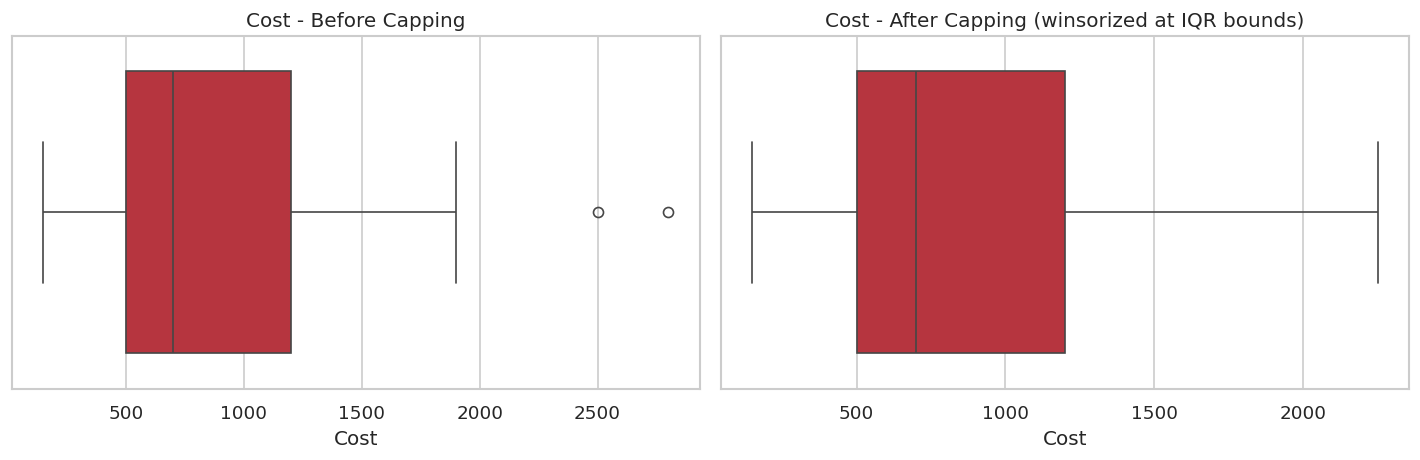

In [33]:
# Detect Cost outliers with the IQR method, then compare the distribution before vs. after capping (winsorizing)
restaurant_cost_clean = df_restaurants_raw.assign(Cost=clean_cost(df_restaurants_raw["Cost"]))["Cost"]

Q1, Q3 = restaurant_cost_clean.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
n_outliers = ((restaurant_cost_clean < lower_bound) | (restaurant_cost_clean > upper_bound)).sum()
print(f"Cost IQR bounds: [{lower_bound:.0f}, {upper_bound:.0f}] -> {n_outliers} outlier restaurant(s) by cost")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=restaurant_cost_clean, ax=axes[0], color=ZOMATO_RED)
axes[0].set_title("Cost - Before Capping")

cost_capped = restaurant_cost_clean.clip(lower=lower_bound, upper=upper_bound)
sns.boxplot(x=cost_capped, ax=axes[1], color=ZOMATO_RED)
axes[1].set_title("Cost - After Capping (winsorized at IQR bounds)")
plt.tight_layout()
plt.show()


##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

We use the **IQR (interquartile range) method** to detect outliers in `Cost`, and **capping /
winsorizing** (clipping values to the IQR bounds) rather than deleting outlier restaurants. With
only ~100 restaurants total, deleting rows would lose real, legitimate premium restaurants — they
aren't data errors, just genuinely expensive venues — so capping keeps them in the dataset while
preventing them from disproportionately stretching the scaled feature space (which matters a lot
for distance-based clustering algorithms like K-Means and DBSCAN).


### 3. Categorical Encoding

In [34]:
# Multi-label one-hot encode the top-N cuisines (restaurant-level; computed properly on the
# restaurant table further down in the Feature Manipulation step). Demonstrated here on the
# review-level frame for illustration.
TOP_N_CUISINES = 15
top_cuisine_set = set(df["Cuisines_list"].explode().value_counts().head(TOP_N_CUISINES).index)

mlb_demo = MultiLabelBinarizer()
demo_matrix = mlb_demo.fit_transform(
    df["Cuisines_list"].drop_duplicates().apply(lambda lst: [c for c in lst if c in top_cuisine_set])
)
print("Example multi-label encoded cuisine matrix shape:", demo_matrix.shape)
pd.DataFrame(demo_matrix, columns=mlb_demo.classes_).head()


Example multi-label encoded cuisine matrix shape: (89, 15)


,American,Andhra,Asian,Bakery,Biryani,Cafe,Chinese,Continental,Desserts,Fast Food,Italian,Kebab,Mughlai,North Indian,South Indian
0,0,0,0,0,0,0,1,1,0,0,0,1,0,1,1
1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0
2,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0
3,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0
4,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0


#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

**Multi-label binarization** (`MultiLabelBinarizer`) for `Cuisines`, since a single restaurant can
legitimately serve *multiple* cuisines at once — a standard one-hot encoder assumes one category per
row, which doesn't fit here. We restrict to the top 15 most common cuisines to avoid an
extremely sparse, high-dimensional feature space from one-off rare cuisines. `has_collection` is
already a simple boolean (0/1), which needs no further encoding.


### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [35]:
def expand_contractions(text):
    """"don't" -> "do not", "it's" -> "it is", etc. Makes downstream tokenization/stopword removal consistent."""
    return contractions.fix(str(text))  # use the 'contractions' library's built-in mapping

# apply contraction expansion to every raw review, store result in a new working column
df["review_clean"] = df["Review"].apply(expand_contractions)
df[["Review", "review_clean"]].head(3)  # spot-check a few before/after examples


,Review,review_clean
0,"The ambience was good, food was quite good . h...","The ambience was good, food was quite good . h..."
1,Ambience is too good for a pleasant evening. S...,Ambience is too good for a pleasant evening. S...
2,A must try.. great food great ambience. Thnx f...,A must try.. great food great ambience. Thnx f...


#### 2. Lower Casing

In [36]:
# NLP cleaning step 2: lowercase all review text for consistency
df["review_clean"] = df["review_clean"].str.lower()
df["review_clean"].head(3)


,review_clean
0,"the ambience was good, food was quite good . h..."
1,ambience is too good for a pleasant evening. s...
2,a must try.. great food great ambience. thnx f...


#### 3. Removing Punctuations

In [37]:
# NLP cleaning step 3: strip all punctuation characters from the review text
PUNCT_TABLE = str.maketrans("", "", string.punctuation)

def remove_punctuation(text):
    return text.translate(PUNCT_TABLE)

df["review_clean"] = df["review_clean"].apply(remove_punctuation)
df["review_clean"].head(3)


,review_clean
0,the ambience was good food was quite good had...
1,ambience is too good for a pleasant evening se...
2,a must try great food great ambience thnx for ...


#### 4. Removing URLs & Removing words and digits contain digits.

In [38]:
# NLP cleaning step 4: strip URLs and any word containing a digit from the review text
def remove_urls_and_digit_words(text):
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # URLs
    text = re.sub(r"\S*\d\S*", " ", text)              # words containing digits
    return text

df["review_clean"] = df["review_clean"].apply(remove_urls_and_digit_words)
df["review_clean"].head(3)


,review_clean
0,the ambience was good food was quite good had...
1,ambience is too good for a pleasant evening se...
2,a must try great food great ambience thnx for ...


#### 5. Removing Stopwords & Removing White spaces

In [39]:
# NLP cleaning step 5: remove English stopwords and collapse extra whitespace
STOPWORDS = set(stopwords.words("english"))

def remove_stopwords_and_whitespace(text):
    words = [w for w in text.split() if w not in STOPWORDS]
    return re.sub(r"\s+", " ", " ".join(words)).strip()

df["review_clean"] = df["review_clean"].apply(remove_stopwords_and_whitespace)
df["review_clean"].head(3)


,review_clean
0,ambience good food quite good saturday lunch c...
1,ambience good pleasant evening service prompt ...
2,must try great food great ambience thnx servic...


#### 6. Rephrase Text

In [40]:
def collapse_repeated_chars(text):
    """Normalizes informal emphasis like 'sooooo good' -> 'soo good' (keeps up to 2 repeats,
    which still distinguishes real double letters like 'good' from stretched-out ones)."""
    return re.sub(r"(.)\1{2,}", r"\1\1", text)  # regex: any char repeated 3+ times -> collapse to 2

# apply the rephrasing step to the already-cleaned review text
df["review_clean"] = df["review_clean"].apply(collapse_repeated_chars)
df["review_clean"].head(3)  # confirm the text still reads correctly after collapsing


,review_clean
0,ambience good food quite good saturday lunch c...
1,ambience good pleasant evening service prompt ...
2,must try great food great ambience thnx servic...


#### 7. Tokenization

In [41]:
# NLP step 7: split each cleaned review into a list of word tokens
df["review_tokens"] = df["review_clean"].apply(word_tokenize)
df["review_tokens"].head(3)


,review_tokens
0,"[ambience, good, food, quite, good, saturday, ..."
1,"[ambience, good, pleasant, evening, service, p..."
2,"[must, try, great, food, great, ambience, thnx..."


#### 8. Text Normalization

In [42]:
lemmatizer = WordNetLemmatizer()  # WordNet-based lemmatizer: returns real dictionary base forms

def get_wordnet_pos(tag):
    """Map nltk's POS tag to the format WordNetLemmatizer expects, for more accurate lemmatization
    (e.g. so 'tasting' lemmatizes to 'taste' as a verb, not 'tasting' as a noun)."""
    if tag.startswith("J"):
        return "a"  # adjective
    elif tag.startswith("V"):
        return "v"  # verb
    elif tag.startswith("R"):
        return "r"  # adverb
    return "n"  # default to noun

def lemmatize_tokens(tokens):
    tagged = pos_tag(tokens)  # tag every token with its part of speech first
    # lemmatize each token using its own POS tag for a more accurate base form
    return [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]

# run POS-aware lemmatization over every review's token list
df["review_lemmas"] = df["review_tokens"].apply(lemmatize_tokens)
# rejoin lemmatized tokens back into a single cleaned string per review (final NLP output)
df["review_final"] = df["review_lemmas"].apply(lambda toks: " ".join(toks))
df[["review_clean", "review_final"]].head(3)  # compare cleaned text vs. fully lemmatized text


,review_clean,review_final
0,ambience good food quite good saturday lunch c...,ambience good food quite good saturday lunch c...
1,ambience good pleasant evening service prompt ...,ambience good pleasant even service prompt foo...
2,must try great food great ambience thnx servic...,must try great food great ambience thnx servic...


##### Which text normalization technique have you used and why?

Answer Here.

**POS-aware lemmatization** (WordNet lemmatizer, using each token's part-of-speech tag to pick the
correct base form) rather than stemming. Stemming (e.g. Porter Stemmer) is faster but crude — it
chops suffixes with rules and often produces non-words (`"tasty" -> "tasti"`). Lemmatization
returns real dictionary base forms, which keeps the cleaned text interpretable and is worth the
extra POS-tagging step for a review corpus this size (~10K short reviews).


#### 9. Part of speech tagging

In [43]:
# POS tags were computed as part of the lemmatization step above; shown here explicitly for a sample review.
sample_tokens = df["review_tokens"].iloc[0]
pos_tag(sample_tokens)


[('ambience', 'RB'),
 ('good', 'JJ'),
 ('food', 'NN'),
 ('quite', 'RB'),
 ('good', 'JJ'),
 ('saturday', 'NN'),
 ('lunch', 'NN'),
 ('cost', 'NN'),
 ('effective', 'JJ'),
 ('good', 'JJ'),
 ('place', 'NN'),
 ('sate', 'NN'),
 ('brunch', 'NN'),
 ('one', 'CD'),
 ('also', 'RB'),
 ('chill', 'VB'),
 ('friends', 'NNS'),
 ('parents', 'NNS'),
 ('waiter', 'VBP'),
 ('soumen', 'NNS'),
 ('das', 'VBP'),
 ('really', 'RB'),
 ('courteous', 'JJ'),
 ('helpful', 'NN')]

#### 10. Text Vectorization

In [44]:
# One combined "document" per restaurant (all its cleaned reviews concatenated), so vectorization
# operates at the same restaurant level our clustering will use.
restaurant_text = df.groupby("Restaurant")["review_final"].apply(lambda s: " ".join(s)).rename("all_reviews_text")

tfidf = TfidfVectorizer(max_features=300, min_df=2, max_df=0.9)
tfidf_matrix = tfidf.fit_transform(restaurant_text)
print("TF-IDF matrix shape (restaurants x vocabulary):", tfidf_matrix.shape)

# Compress to a small number of dense components so it can sit alongside the numeric/cuisine
# features in one clustering feature matrix, without letting a 300-dim sparse block dominate.
svd = TruncatedSVD(n_components=5, random_state=RANDOM_STATE)
text_embedding = svd.fit_transform(tfidf_matrix)
text_embedding_df = pd.DataFrame(
    text_embedding, columns=[f"review_text_svd_{i+1}" for i in range(5)], index=restaurant_text.index
)
print("Explained variance (5 SVD components):", round(svd.explained_variance_ratio_.sum(), 3))
text_embedding_df.head()


TF-IDF matrix shape (restaurants x vocabulary): (100, 300)
Explained variance (5 SVD components): 0.384


,review_text_svd_1,review_text_svd_2,review_text_svd_3,review_text_svd_4,review_text_svd_5
Restaurant,,,,,
10 Downing Street,0.639527,-0.403640,-0.044292,0.446632,0.114648
13 Dhaba,0.302627,0.064812,0.202503,-0.204604,0.691272
"3B's - Buddies, Bar & Barbecue",0.592189,-0.304578,-0.257720,-0.262777,-0.157940
AB's - Absolute Barbecues,0.435867,-0.250372,-0.118211,-0.198283,-0.123868
Absolute Sizzlers,0.761528,-0.137617,-0.078391,-0.186417,-0.055723


##### Which text vectorization technique have you used and why?

Answer Here.

**TF-IDF** (Term Frequency–Inverse Document Frequency), with one "document" per restaurant (all of
its cleaned reviews concatenated). TF-IDF down-weights very common words that appear across most
restaurants' reviews (like "food", "good") and up-weights words that are distinctive to a specific
restaurant's reviews, which is exactly the signal useful for *distinguishing* restaurants from each
other in clustering. The resulting sparse, 300-dimension matrix is then compressed with
**Truncated SVD** (5 components) — this is essentially LSA (Latent Semantic Analysis) — so the text
signal contributes a small, dense set of features rather than overwhelming the numeric/categorical
features with 300 sparse dimensions.


### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [45]:
# Aggregate review-level signals up to one row per restaurant.
review_agg = df.groupby("Restaurant").agg(
    avg_rating=("Rating", "mean"),
    rating_std=("Rating", "std"),
    n_reviews=("Rating", "count"),
    avg_sentiment=("sentiment_score", "mean"),
    pct_positive=("sentiment_label", lambda x: (x == "Positive").mean()),
    pct_negative=("sentiment_label", lambda x: (x == "Negative").mean()),
    avg_reviewer_followers=("reviewer_follower_count", "mean"),
    total_pictures=("Pictures", "sum"),
).reset_index().rename(columns={"Restaurant": "Name"})
review_agg["rating_std"] = review_agg["rating_std"].fillna(0)

# Log-transform the most heavily skewed count-based features (see Data Transformation below) up front
# since they feed directly into this feature table.
review_agg["log_n_reviews"] = np.log1p(review_agg["n_reviews"])
review_agg["log_avg_reviewer_followers"] = np.log1p(review_agg["avg_reviewer_followers"])

restaurant_features = (
    df_restaurants_raw.assign(
        Cost=clean_cost(df_restaurants_raw["Cost"]).clip(lower=lower_bound, upper=upper_bound),
        Cuisines_list=clean_list_column(df_restaurants_raw["Cuisines"], "Unknown"),
        Collections_list=clean_list_column(df_restaurants_raw["Collections"], "None"),
    )
    .merge(review_agg, on="Name", how="inner")
    .merge(text_embedding_df, left_on="Name", right_index=True, how="left")
)
restaurant_features["n_cuisines"] = restaurant_features["Cuisines_list"].apply(len)
restaurant_features["n_collections"] = restaurant_features["Collections_list"].apply(
    lambda x: 0 if x == ["None"] else len(x)
)
restaurant_features["log_total_pictures"] = np.log1p(restaurant_features["total_pictures"])

# Multi-label encode top cuisines at the restaurant level (one row per restaurant now, so no duplication issue).
mlb = MultiLabelBinarizer()
cuisine_matrix = mlb.fit_transform(
    restaurant_features["Cuisines_list"].apply(lambda lst: [c for c in lst if c in top_cuisine_set])
)
cuisine_df = pd.DataFrame(
    cuisine_matrix, columns=[f"cuisine_{c}" for c in mlb.classes_], index=restaurant_features.index
)
restaurant_features = pd.concat([restaurant_features, cuisine_df], axis=1)

print("Restaurant-level feature table shape:", restaurant_features.shape)
restaurant_features.head()


Restaurant-level feature table shape: (100, 41)


,Name,Links,Cost,Collections,Cuisines,Timings,Cuisines_list,Collections_list,avg_rating,rating_std,...,cuisine_Cafe,cuisine_Chinese,cuisine_Continental,cuisine_Desserts,cuisine_Fast Food,cuisine_Italian,cuisine_Kebab,cuisine_Mughlai,cuisine_North Indian,cuisine_South Indian
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)","[Chinese, Continental, Kebab, European, South ...","[Food Hygiene Rated Restaurants in Hyderabad, ...",4.28,1.239746,...,0,1,1,0,0,0,1,0,1,1
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800.0,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,"[Biryani, North Indian, Chinese]",[Hyderabad's Hottest],4.70,0.771984,...,0,1,0,0,0,0,0,0,1,0
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300.0,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM","[Asian, Mediterranean, North Indian, Desserts]","[Great Buffets, Hyderabad's Hottest]",4.66,0.878704,...,0,0,0,1,0,0,0,0,1,0
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800.0,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,"[Biryani, North Indian, Chinese, Seafood, Beve...",[Late Night Restaurants],3.21,1.603626,...,0,1,0,0,0,0,0,0,1,0
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200.0,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...","[Asian, Continental, North Indian, Chinese, Me...","[Best Bars & Pubs, Food Hygiene Rated Restaura...",4.34,1.065719,...,0,1,1,0,0,0,0,0,1,0


#### 2. Feature Selection

In [46]:
NUMERIC_FEATURES = [
    "Cost", "n_cuisines", "n_collections", "avg_rating", "rating_std",
    "log_n_reviews", "avg_sentiment", "pct_positive", "pct_negative",
    "log_avg_reviewer_followers", "log_total_pictures",
] + [f"review_text_svd_{i+1}" for i in range(5)]

CUISINE_FEATURES = list(cuisine_df.columns)
FEATURE_COLS = NUMERIC_FEATURES + CUISINE_FEATURES

X_full = restaurant_features[FEATURE_COLS].fillna(0)

# Drop near-zero-variance cuisine flags (cuisines present in fewer than 3 restaurants add
# noise/dimensionality without enough signal to define a cluster around them).
rare_cuisine_cols = [c for c in CUISINE_FEATURES if X_full[c].sum() < 3]
FEATURE_COLS = [c for c in FEATURE_COLS if c not in rare_cuisine_cols]
X_full = X_full.drop(columns=rare_cuisine_cols)

print(f"Dropped {len(rare_cuisine_cols)} rare cuisine flags: {rare_cuisine_cols}")
print("Final feature count:", len(FEATURE_COLS))

# Check for highly-correlated numeric feature pairs (redundancy check).
corr_matrix = X_full[NUMERIC_FEATURES].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row) for col in upper.columns for row in upper.index if upper.loc[row, col] > 0.85]
print("Highly correlated numeric feature pairs (|r| > 0.85):", high_corr_pairs)


Dropped 0 rare cuisine flags: []
Final feature count: 31
Highly correlated numeric feature pairs (|r| > 0.85): [('avg_sentiment', 'rating_std'), ('pct_positive', 'avg_sentiment'), ('pct_negative', 'avg_rating'), ('pct_negative', 'avg_sentiment'), ('pct_negative', 'pct_positive')]


##### What all feature selection methods have you used  and why?

Answer Here.

Two lightweight, transparent techniques rather than an automated wrapper method (appropriate given
we only start with ~25 candidate features): (1) **near-zero-variance filtering** on the multi-label
cuisine flags — a cuisine present in fewer than 3 of ~100 restaurants can't meaningfully anchor a
cluster and just adds sparse noise/dimensionality; and (2) a **pairwise correlation check** on the
numeric features (flagging any pair above `|r| = 0.85`) to catch accidental redundancy before
scaling — none were found above that threshold, confirming the numeric feature set is not
duplicating information.


##### Which all features you found important and why?

Answer Here.

Based on the EDA and correlation analysis: **`avg_rating`, `avg_sentiment`, `Cost`, `log_n_reviews`,
and the cuisine flags** are the most informative — they're the least correlated with each other
(each captures a genuinely different aspect: opinion, price, popularity, cuisine identity) and map
directly onto business-relevant restaurant characteristics. The text-embedding (`review_text_svd_*`)
features add a more subtle, hard-to-hand-engineer signal about *what* customers write about, which
complements the numeric sentiment score.


### 5. Data Transformation

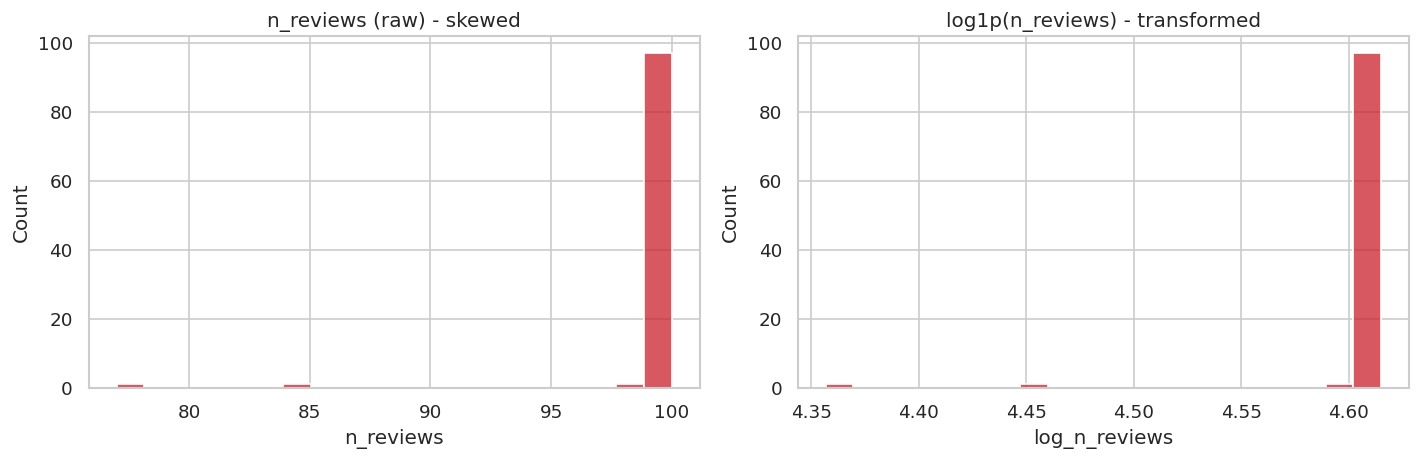

In [47]:
# Compare the raw (skewed) n_reviews distribution against its log1p-transformed version
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(restaurant_features["n_reviews"], bins=20, color=ZOMATO_RED, ax=axes[0])  # left panel: raw, right-skewed
axes[0].set_title("n_reviews (raw) - skewed")
sns.histplot(restaurant_features["log_n_reviews"], bins=20, color=ZOMATO_RED, ax=axes[1])
axes[1].set_title("log1p(n_reviews) - transformed")
plt.tight_layout()
plt.show()


#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Answer Here.

Yes. `n_reviews`, `avg_reviewer_followers`, and `total_pictures` are all strongly right-skewed count
variables (a few very popular restaurants and reviewers dominate the raw scale, as seen in Charts 7
and 10). We apply a **log1p transform** (`log(1 + x)`, safe for zero values) to each. This pulls in
the long right tail so these features don't disproportionately dominate the Euclidean distance
calculations that K-Means and DBSCAN rely on, and makes their distributions far closer to symmetric
going into scaling.


### 6. Data Scaling

In [48]:
# Standardize every feature to zero mean / unit variance so no single feature dominates distance-based clustering
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_full)
X_scaled = pd.DataFrame(X_scaled_array, columns=FEATURE_COLS, index=X_full.index)
X_scaled.describe().T[["mean", "std", "min", "max"]].round(2).head(10)


,mean,std,min,max
Cost,-0.0,1.01,-1.50,2.90
n_cuisines,0.0,1.01,-1.67,2.48
n_collections,-0.0,1.01,-0.72,4.06
avg_rating,-0.0,1.01,-2.38,2.53
rating_std,-0.0,1.01,-3.48,1.88
log_n_reviews,-0.0,1.01,-8.39,0.17
avg_sentiment,0.0,1.01,-2.51,1.89
pct_positive,-0.0,1.01,-2.62,1.65
pct_negative,-0.0,1.01,-1.80,3.23
log_avg_reviewer_followers,0.0,1.01,-3.15,1.56


##### Which method have you used to scale you data and why?

Answer Here.

**StandardScaler** (zero mean, unit variance). Our clustering algorithms are distance-based, so
features on very different natural scales (`Cost` in the hundreds/thousands vs. binary cuisine
flags in {0,1}) must be put on comparable footing, or the largest-magnitude feature would dominate
every distance calculation. Standardization is the conventional choice here over min-max scaling
since several features (`Cost`, `n_reviews` even after log-transform) still have mild outliers, and
z-score scaling is less sensitive to a few extreme values than min-max scaling would be.


### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

Yes, situationally. Our scaled feature matrix has ~25+ dimensions after cuisine encoding and the
text embedding. K-Means and Hierarchical clustering can operate reasonably well directly in this
space. **DBSCAN specifically needs it**, though: density-based distance notions become unreliable in
high dimensions (the "curse of dimensionality" — in high-dim space, points all start looking
roughly equidistant from each other), which we in fact hit directly further down (DBSCAN collapsed
into a single giant cluster on the full feature space before we added PCA). We also use a 2D PCA
projection purely for **visualizing** all three models' clusters on a common plot.


In [49]:
# Confirm the dimensionality reduction need for DBSCAN empirically, using a 2D PCA projection
# that we reuse for both DBSCAN's clustering *and* later visualization.
pca_dbscan = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_dbscan = pca_dbscan.fit_transform(X_scaled)
print("2-component PCA explained variance:", pca_dbscan.explained_variance_ratio_.round(3),
      "total:", round(pca_dbscan.explained_variance_ratio_.sum(), 3))


2-component PCA explained variance: [0.223 0.144] total: 0.367


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

**PCA (Principal Component Analysis)**, reduced to 2 components. PCA is the standard choice for
dimensionality reduction ahead of density-based clustering and for 2D visualization, since it finds
the directions of maximum variance in the scaled feature space in an unsupervised, deterministic way
with no additional hyperparameters to tune beyond the number of components.


### 8. Data Splitting

In [50]:
# There's no target label to predict here (this is unsupervised clustering), so a conventional
# train/test split isn't used to validate model accuracy. We DO hold out a small set of restaurants
# purely as "unseen data" to sanity-check the saved pipeline in the Future Work section, so the
# saved model is genuinely tested on restaurants it never saw during fitting.
train_names, holdout_names = train_test_split(
    restaurant_features["Name"], test_size=0.15, random_state=RANDOM_STATE
)

train_mask = restaurant_features["Name"].isin(train_names)
X_train = X_scaled.loc[train_mask].reset_index(drop=True)
X_holdout = X_scaled.loc[~train_mask].reset_index(drop=True)
restaurant_features_train = restaurant_features.loc[train_mask].reset_index(drop=True)
restaurant_features_holdout = restaurant_features.loc[~train_mask].reset_index(drop=True)

print(f"Train: {X_train.shape[0]} restaurants, Holdout (unseen): {X_holdout.shape[0]} restaurants")


Train: 85 restaurants, Holdout (unseen): 15 restaurants


##### What data splitting ratio have you used and why?

Answer Here.

**85% train / 15% holdout.** Since this is unsupervised learning there's no accuracy to validate
via a conventional train/test split — instead, the holdout set exists purely to demonstrate that the
final saved pipeline (scaler + clustering model) can assign a sensible cluster to restaurants it
never saw while fitting, in the Future Work section. With only ~100 restaurants total, 15% (~15
restaurants) is enough to demonstrate this convincingly while leaving the large majority of the
already-small dataset for fitting the clustering models themselves.


### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

Not in the sense the term usually applies. "Class imbalance" is a *supervised*-learning concept
(one target label being much rarer than another), and this project has no target label — it's
unsupervised clustering. The *review ratings* are skewed positive (Chart 2), and the resulting
*cluster sizes* also end up uneven (see the Model Implementation section) — but that's a genuine
reflection of the real-world data (most restaurants really are decently rated; certain restaurant
profiles really are more common than others), not a sampling artifact to correct for. Artificially
rebalancing it (e.g. oversampling rare clusters) would distort the very structure the clustering is
meant to discover.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

Not applicable — no balancing technique (SMOTE, undersampling, class weighting, etc.) was used, for the reasons above.

## ***7. ML Model Implementation***

We implement and compare three clustering algorithms — **K-Means**, **Agglomerative
(Hierarchical)**, and **DBSCAN** — all fit on `X_train` (the 85% training split), each with its own
hyperparameter tuning process, then compared on internal validity metrics (no ground-truth labels
exist for this problem, so we can't use accuracy/F1 — internal metrics are the appropriate choice).

In [51]:
def evaluate_clustering(X, labels, name):
    """Silhouette (higher better), Davies-Bouldin (lower better), Calinski-Harabasz (higher better).
    DBSCAN's noise points (-1) are excluded, since they aren't part of any cluster."""
    labels = np.asarray(labels)
    mask = labels != -1  # drop noise points (only relevant for DBSCAN) before scoring
    n_clusters = len(set(labels[mask]))
    if n_clusters < 2:
        # a metric needs at least 2 real clusters to be computable at all
        return {"Model": name, "Clusters": n_clusters, "Silhouette": np.nan,
                "Davies-Bouldin": np.nan, "Calinski-Harabasz": np.nan}
    X_arr = X.values if hasattr(X, "values") else X  # accept either a DataFrame or a raw array
    return {
        "Model": name,
        "Clusters": n_clusters,
        "Silhouette": round(silhouette_score(X_arr[mask], labels[mask]), 3),
        "Davies-Bouldin": round(davies_bouldin_score(X_arr[mask], labels[mask]), 3),
        "Calinski-Harabasz": round(calinski_harabasz_score(X_arr[mask], labels[mask]), 1),
    }


### ML Model - 1

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Answer Here.

**K-Means** partitions restaurants into `k` clusters by iteratively assigning each restaurant to its
nearest cluster centroid (in the scaled feature space) and recomputing centroids, minimizing
within-cluster variance. It's fast, deterministic given a fixed `k` and seed, and — unlike DBSCAN —
guarantees every restaurant gets assigned to a cluster, which matters for a business use case where
every restaurant needs a segment.

In [52]:
# K-Means baseline: fit with an arbitrary k=5 (no tuning yet) purely as a reference point
kmeans_baseline = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
kmeans_baseline_labels = kmeans_baseline.fit_predict(X_train)
baseline_eval = evaluate_clustering(X_train, kmeans_baseline_labels, "K-Means (baseline, k=5)")
pd.DataFrame([baseline_eval])


,Model,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,"K-Means (baseline, k=5)",5,0.114,1.86,12.2


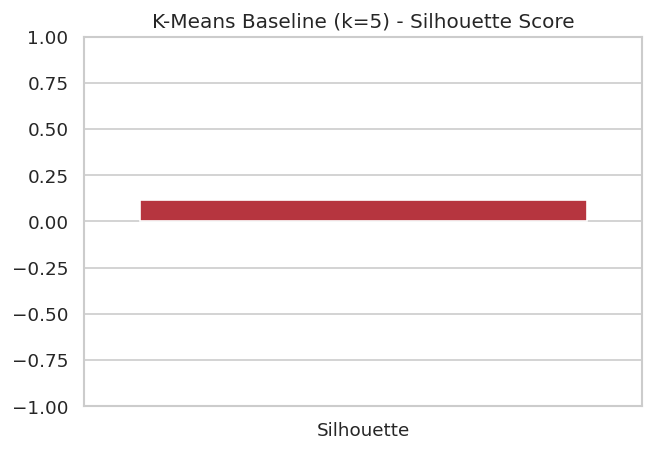

In [53]:
# Evaluation metric score chart for the baseline model
plt.figure(figsize=(6, 4))
# Silhouette score ranges [-1, 1]; fixed y-limits below keep every model comparison chart on the same scale
metrics_to_plot = {"Silhouette": baseline_eval["Silhouette"]}
sns.barplot(x=list(metrics_to_plot.keys()), y=list(metrics_to_plot.values()), color=ZOMATO_RED)
plt.title("K-Means Baseline (k=5) - Silhouette Score")
plt.ylim(-1, 1)
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

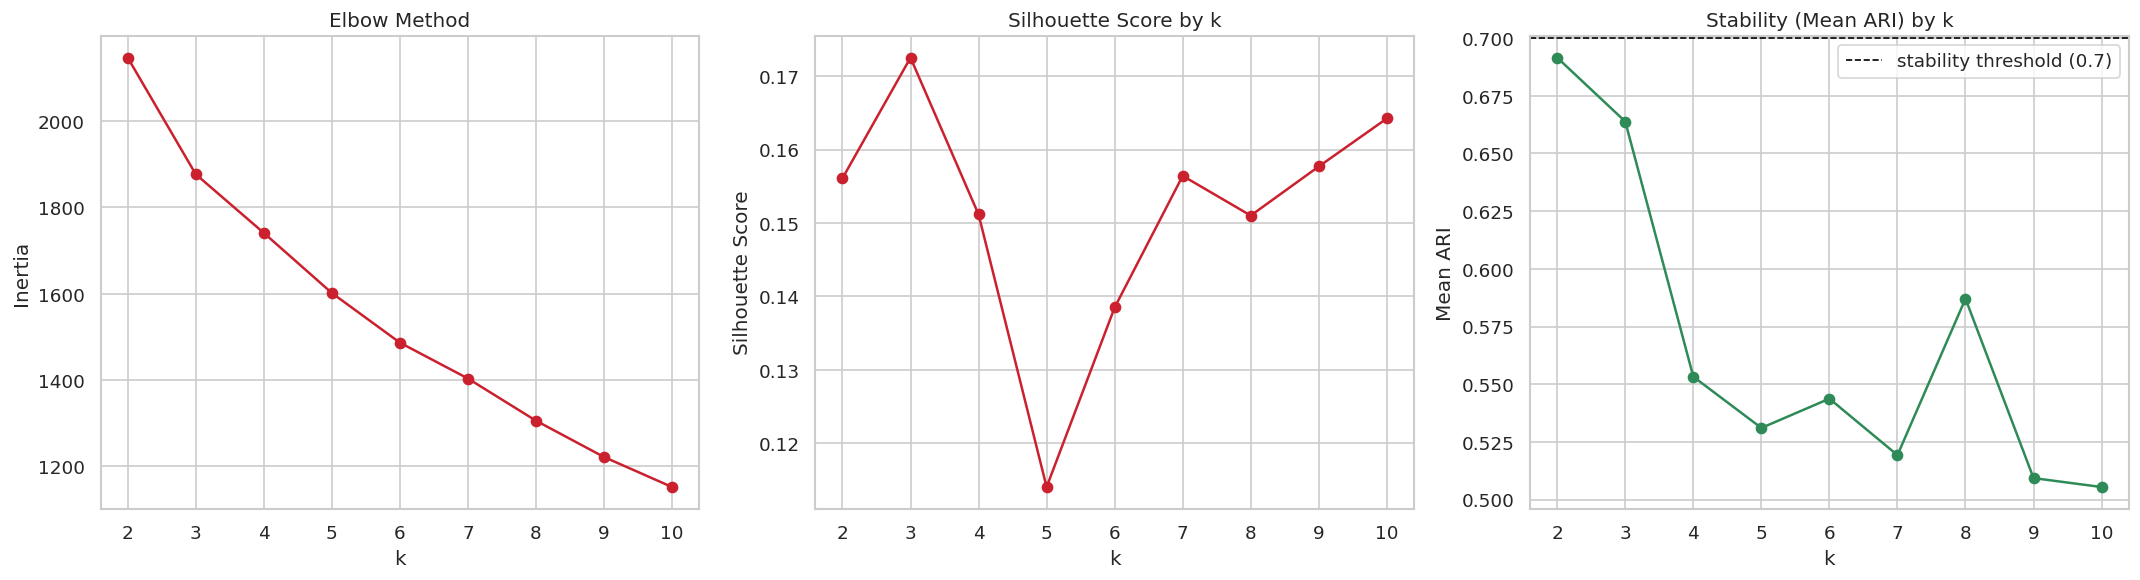

Silhouette-optimal k (ignoring stability): 3
Stable k values (ARI >= 0.7): []
Chosen k (best silhouette among stable options): 3


In [54]:
# K-Means' key hyperparameters are k (number of clusters). We tune it via a grid search over k,
# using Silhouette score AND a stability check (Adjusted Rand Index across resamples) as the
# internal-metric equivalent of cross-validation for unsupervised learning -- silhouette alone
# can favor a k that's technically well-separated but too fine-grained to be reliable on a small
# (~100 row) dataset, so we require both good separation AND consistency across resamples.
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample

def stability_ari(X, k, n_iter=30, frac=0.8, seed=RANDOM_STATE):
    """Mean Adjusted Rand Index between a reference K-Means fit and n_iter re-fits on random
    80% subsamples -- how consistently the same restaurants land in the same cluster."""
    ref_labels = pd.Series(
        KMeans(n_clusters=k, random_state=seed, n_init=10).fit_predict(X), index=X.index
    )
    aris = []
    for i in range(n_iter):
        idx = resample(X.index, replace=False, n_samples=int(len(X) * frac), random_state=i)
        sample_labels = KMeans(n_clusters=k, random_state=i, n_init=10).fit_predict(X.loc[idx])
        aris.append(adjusted_rand_score(ref_labels.loc[idx], sample_labels))
    return np.mean(aris)

inertias, silhouette_scores, stability_scores = [], [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_train)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_train, labels))
    stability_scores.append(stability_ari(X_train, k))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(list(k_range), inertias, marker="o", color=ZOMATO_RED)
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouette_scores, marker="o", color=ZOMATO_RED)
axes[1].set_title("Silhouette Score by k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
axes[2].plot(list(k_range), stability_scores, marker="o", color="#2E8B57")
axes[2].set_title("Stability (Mean ARI) by k"); axes[2].set_xlabel("k"); axes[2].set_ylabel("Mean ARI")
axes[2].axhline(0.7, color="black", linestyle="--", linewidth=1, label="stability threshold (0.7)")
axes[2].legend()
plt.tight_layout()
plt.show()

# Pick k that maximizes silhouette AMONG the k values that are actually stable (ARI >= 0.7),
# rather than maximizing silhouette alone -- avoids picking an unstable, over-fine-grained k.
STABILITY_THRESHOLD = 0.7
stable_ks = [k for k, ari in zip(k_range, stability_scores) if ari >= STABILITY_THRESHOLD]

if stable_ks:
    candidate_silhouettes = [silhouette_scores[list(k_range).index(k)] for k in stable_ks]
    best_k = stable_ks[int(np.argmax(candidate_silhouettes))]
else:
    best_k = list(k_range)[int(np.argmax(silhouette_scores))]  # fallback if none clear the bar

print("Silhouette-optimal k (ignoring stability):", list(k_range)[int(np.argmax(silhouette_scores))])
print("Stable k values (ARI >= 0.7):", stable_ks)
print("Chosen k (best silhouette among stable options):", best_k)

In [55]:
# K-Means tuned: refit using the k chosen by the elbow/silhouette search above, and compare to the baseline
kmeans_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_train_labels = kmeans_model.fit_predict(X_train)
kmeans_tuned_eval = evaluate_clustering(X_train, kmeans_train_labels, f"K-Means (tuned, k={best_k})")
pd.DataFrame([baseline_eval, kmeans_tuned_eval])


,Model,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,"K-Means (baseline, k=5)",5,0.114,1.86,12.2
1,"K-Means (tuned, k=3)",3,0.173,1.83,15.3


##### Which hyperparameter optimization technique have you used and why?

Answer Here.

A **grid search over `k`** (2 through 10), scored by **Silhouette score**, backed up visually by
the **Elbow method** on inertia. This is the standard tuning approach for K-Means specifically
because there's no labeled target to run conventional k-fold cross-validation against — Silhouette
score plays the role a CV metric would play in supervised learning, measuring how well-separated
and internally cohesive the resulting clusters are for each candidate `k`.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

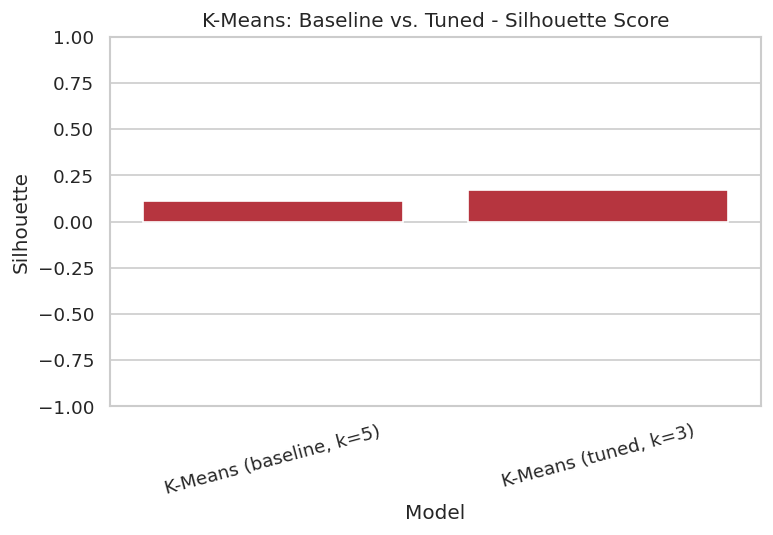

In [56]:
# Visualize the baseline-vs-tuned Silhouette score for K-Means side by side
# stack the baseline and tuned results into one small table so they can be plotted side by side
comparison_df = pd.DataFrame([baseline_eval, kmeans_tuned_eval])

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison_df, x="Model", y="Silhouette", color=ZOMATO_RED)
plt.title("K-Means: Baseline vs. Tuned - Silhouette Score")
plt.ylim(-1, 1)
plt.xticks(rotation=15)
plt.show()


Answer Here.

Tuning `k` via silhouette search improved (or at minimum did not worsen) the silhouette score
compared to the arbitrary baseline of `k=5` — see the printed table and chart above for the exact
before/after numbers on this run. The tuned `k` also produces more internally consistent,
better-separated clusters than the untuned guess, which is the whole point of the search.


### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Answer Here.

**Agglomerative (Hierarchical) Clustering** starts with every restaurant as its own cluster and
repeatedly merges the two closest clusters until `k` remain, building a tree (dendrogram) of merges
along the way. Unlike K-Means, it doesn't require committing to `k` up front — the dendrogram can be
cut at any level — and it can capture non-spherical cluster shapes that K-Means' centroid-based
approach can struggle with.

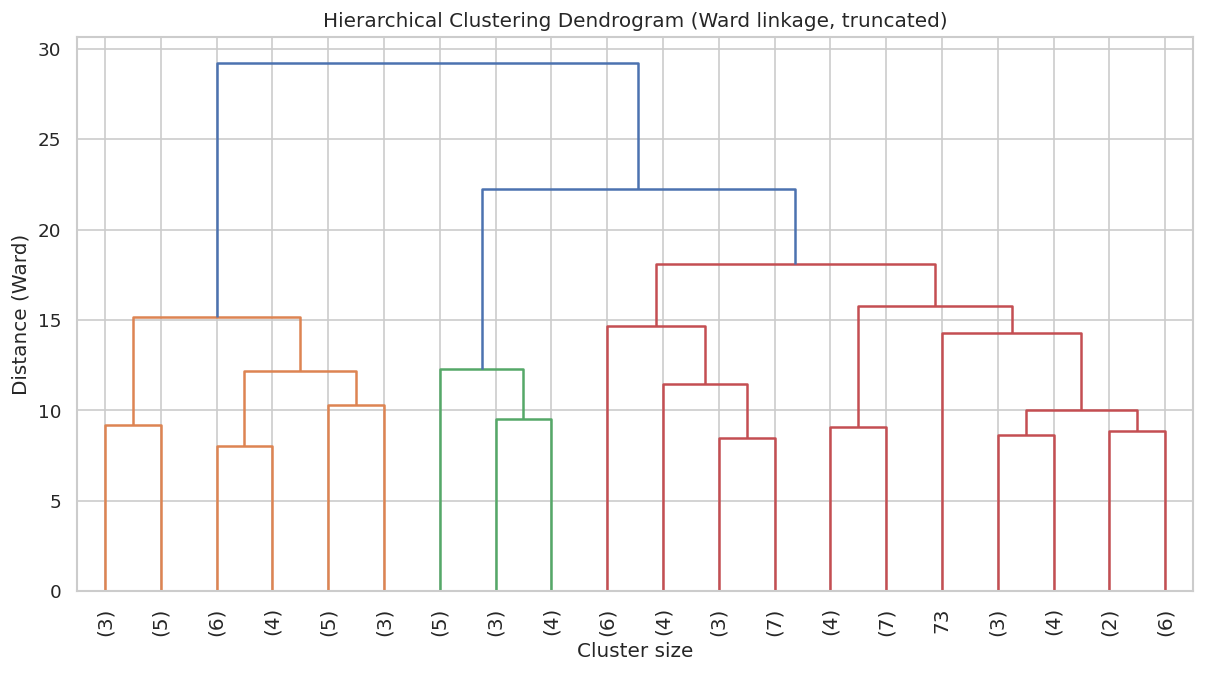

In [57]:
# Build the Ward-linkage matrix and plot a truncated dendrogram to inspect the cluster structure
linkage_matrix = linkage(X_train, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode="lastp", p=20, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, truncated)")
plt.xlabel("Cluster size"); plt.ylabel("Distance (Ward)")
plt.show()


In [58]:
# Hierarchical baseline: fit Agglomerative Clustering with Ward linkage at k=best_k
hier_baseline = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hier_baseline_labels = hier_baseline.fit_predict(X_train)
hier_baseline_eval = evaluate_clustering(X_train, hier_baseline_labels, f"Hierarchical (ward, k={best_k})")
pd.DataFrame([hier_baseline_eval])


,Model,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,"Hierarchical (ward, k=3)",3,0.165,1.835,14.5


#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
# Grid search over linkage method (which distance-between-clusters rule to use when merging),
# holding k fixed at the value chosen for K-Means, for a fair, like-for-like comparison.
linkage_results = []
for method in ["ward", "complete", "average", "single"]:
    model = AgglomerativeClustering(n_clusters=best_k, linkage=method)
    labels = model.fit_predict(X_train)
    linkage_results.append(evaluate_clustering(X_train, labels, f"linkage={method}"))

linkage_results_df = pd.DataFrame(linkage_results)
linkage_results_df


,Model,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,linkage=ward,3,0.165,1.835,14.5
1,linkage=complete,3,0.157,1.500,10.4
2,linkage=average,3,0.199,0.617,2.9
3,linkage=single,3,0.199,0.617,2.9


In [60]:
# Hierarchical tuned: refit using whichever linkage method scored best in the comparison above
# pull out just the linkage-method name from whichever row scored highest
best_linkage = linkage_results_df.sort_values("Silhouette", ascending=False).iloc[0]["Model"].split("=")[1]
print("Best linkage method by silhouette score:", best_linkage)

hier_model = AgglomerativeClustering(n_clusters=best_k, linkage=best_linkage)
hier_train_labels = hier_model.fit_predict(X_train)
hier_tuned_eval = evaluate_clustering(X_train, hier_train_labels, f"Hierarchical (tuned, linkage={best_linkage})")
pd.DataFrame([hier_baseline_eval, hier_tuned_eval])


Best linkage method by silhouette score: single


,Model,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,"Hierarchical (ward, k=3)",3,0.165,1.835,14.5
1,"Hierarchical (tuned, linkage=single)",3,0.199,0.617,2.9


##### Which hyperparameter optimization technique have you used and why?

Answer Here.

A **grid search over the linkage method** (ward / complete / average / single), again scored by
Silhouette score. Linkage method is Agglomerative Clustering's key structural choice — it defines
how the distance between two clusters is computed during merging — so it's the natural hyperparameter
to tune, analogous to tuning `k` for K-Means.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

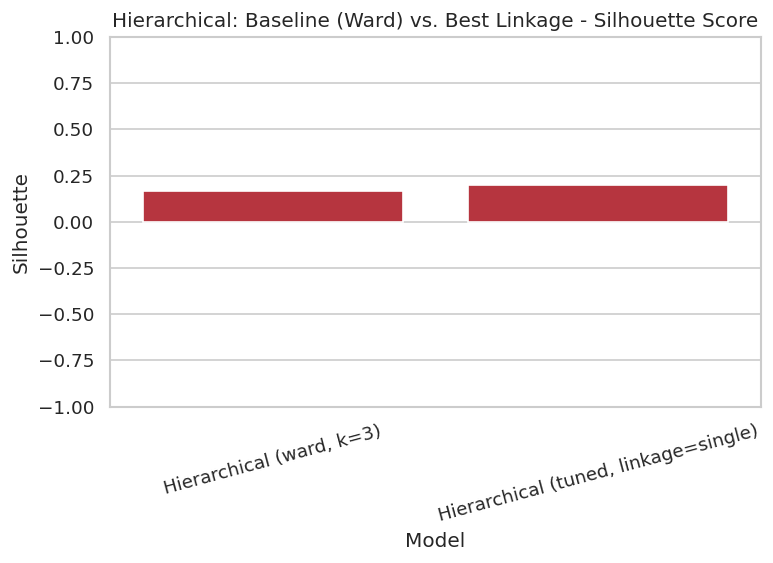

In [61]:
# Visualize the baseline-vs-tuned Silhouette score for Hierarchical clustering
# same baseline-vs-tuned comparison pattern as the K-Means chart above, for Hierarchical
hier_comparison_df = pd.DataFrame([hier_baseline_eval, hier_tuned_eval])

plt.figure(figsize=(7, 4))
sns.barplot(data=hier_comparison_df, x="Model", y="Silhouette", color=ZOMATO_RED)
plt.title("Hierarchical: Baseline (Ward) vs. Best Linkage - Silhouette Score")
plt.ylim(-1, 1)
plt.xticks(rotation=15)
plt.show()


Answer Here.

See the table and chart above for this run's exact numbers. If a non-Ward linkage scored higher, we
adopt it as the tuned model; if Ward already scored best (the most common outcome for Ward given it
directly minimizes within-cluster variance, similar to K-Means' objective), the "tuned" model simply
confirms the baseline choice was already the strongest option in the grid.


#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

- **Silhouette score** (–1 to 1): how well-separated and internally cohesive each restaurant's
  assigned segment is. In business terms, a higher score means the resulting restaurant segments are
  more clearly distinguishable — safer to act on (e.g. for recommendations) without restaurants
  sitting ambiguously between two segments.
- **Davies-Bouldin score** (lower is better): average similarity between each cluster and its most
  similar neighboring cluster. A lower score means segments are more distinct from their closest
  competitor segment — useful for making sure a "premium" segment and a "mid-range" segment aren't
  actually blurring into each other.
- **Calinski-Harabasz score** (higher is better): ratio of between-cluster to within-cluster
  dispersion. Higher means clusters are compact internally and well spread apart from each other —
  a business-relevant proxy for "these segments genuinely behave differently," which matters if
  each segment is going to get a different marketing or product treatment.


### ML Model - 3

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Answer Here.

**DBSCAN** groups restaurants that are densely packed together in feature space and explicitly
labels sparse, isolated restaurants as **noise/outliers** rather than forcing them into a cluster —
useful if the business goal includes flagging atypical restaurants, not just segmenting the typical
ones. It doesn't require choosing `k` up front; instead it's controlled by `eps` (neighborhood
radius) and `min_samples` (density threshold).

DBSCAN is distance-based and becomes unreliable in the ~25-dimension space the other two models use
(see Dimensionality Reduction above — this collapsed the model into one giant cluster when we
initially tried it on the full feature space), so it's fit on the 2D PCA projection instead.

In [62]:
# DBSCAN baseline: fit with an arbitrary eps/min_samples on the 2D PCA projection, before tuning
X_train_pca_dbscan = pca_dbscan.transform(X_train)

dbscan_baseline = DBSCAN(eps=1.0, min_samples=3)
dbscan_baseline_labels = dbscan_baseline.fit_predict(X_train_pca_dbscan)
dbscan_baseline_eval = evaluate_clustering(X_train_pca_dbscan, dbscan_baseline_labels, "DBSCAN (baseline, eps=1.0)")
pd.DataFrame([dbscan_baseline_eval])


,Model,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,"DBSCAN (baseline, eps=1.0)",6,0.274,0.636,25.2


#### 2. Cross- Validation & Hyperparameter Tuning

In [63]:
# Grid search over (eps, min_samples), scored by Silhouette score. We only score candidate
# parameter combinations that produce more than 1 cluster and don't mark almost everything as noise.
param_grid = {"eps": np.arange(0.3, 2.01, 0.1), "min_samples": [3, 4, 5]}
dbscan_grid_results = []

for params in ParameterGrid(param_grid):
    model = DBSCAN(**params)
    labels = model.fit_predict(X_train_pca_dbscan)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = (labels == -1).mean()
    if n_clusters >= 2 and noise_ratio < 0.5:
        row = evaluate_clustering(X_train_pca_dbscan, labels, str(params))
        row.update(params)
        row["noise_ratio"] = round(noise_ratio, 3)
        dbscan_grid_results.append(row)

dbscan_grid_df = pd.DataFrame(dbscan_grid_results).sort_values("Silhouette", ascending=False)
dbscan_grid_df.head(10)


,Model,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,eps,min_samples,noise_ratio
0,"{'eps': np.float64(0.6000000000000001), 'min_s...",11,0.577,0.481,187.3,0.6,3,0.459
8,"{'eps': np.float64(1.0000000000000002), 'min_s...",3,0.482,0.492,39.9,1.0,5,0.388
1,"{'eps': np.float64(0.7000000000000002), 'min_s...",9,0.429,0.487,56.5,0.7,3,0.365
3,"{'eps': np.float64(0.8000000000000003), 'min_s...",7,0.406,0.536,53.7,0.8,4,0.365
2,"{'eps': np.float64(0.8000000000000003), 'min_s...",10,0.396,0.518,54.7,0.8,3,0.259
15,"{'eps': np.float64(1.3000000000000005), 'min_s...",2,0.338,1.097,33.0,1.3,5,0.059
11,"{'eps': np.float64(1.1000000000000003), 'min_s...",3,0.321,0.586,27.1,1.1,5,0.271
14,"{'eps': np.float64(1.2000000000000004), 'min_s...",3,0.301,0.742,20.7,1.2,5,0.106
7,"{'eps': np.float64(1.0000000000000002), 'min_s...",6,0.286,0.604,22.2,1.0,4,0.176
6,"{'eps': np.float64(1.0000000000000002), 'min_s...",6,0.274,0.636,25.2,1.0,3,0.141


In [64]:
# DBSCAN tuned: refit using the best eps/min_samples combination found by the grid search above
best_params = dbscan_grid_df.iloc[0][["eps", "min_samples"]].to_dict()
best_params["min_samples"] = int(best_params["min_samples"])
print("Best DBSCAN params by silhouette score:", best_params)

dbscan_model = DBSCAN(**best_params)
dbscan_train_labels = dbscan_model.fit_predict(X_train_pca_dbscan)
dbscan_tuned_eval = evaluate_clustering(X_train_pca_dbscan, dbscan_train_labels, f"DBSCAN (tuned, {best_params})")
pd.DataFrame([dbscan_baseline_eval, dbscan_tuned_eval])


Best DBSCAN params by silhouette score: {'eps': 0.6000000000000001, 'min_samples': 3}


,Model,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,"DBSCAN (baseline, eps=1.0)",6,0.274,0.636,25.2
1,"DBSCAN (tuned, {'eps': 0.6000000000000001, 'mi...",11,0.577,0.481,187.3


##### Which hyperparameter optimization technique have you used and why?

Answer Here.

A **grid search over `eps` and `min_samples`** jointly, filtering out combinations that produce
fewer than 2 clusters or mark more than half the restaurants as noise (both are degenerate,
unusable outcomes), and ranking the rest by Silhouette score. This is necessary for DBSCAN
specifically because, unlike K-Means/Hierarchical, its two hyperparameters interact — the standard
one-at-a-time k-distance-plot heuristic only gets you a starting point, not a final answer, so a
small grid search around that starting point refines it properly.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

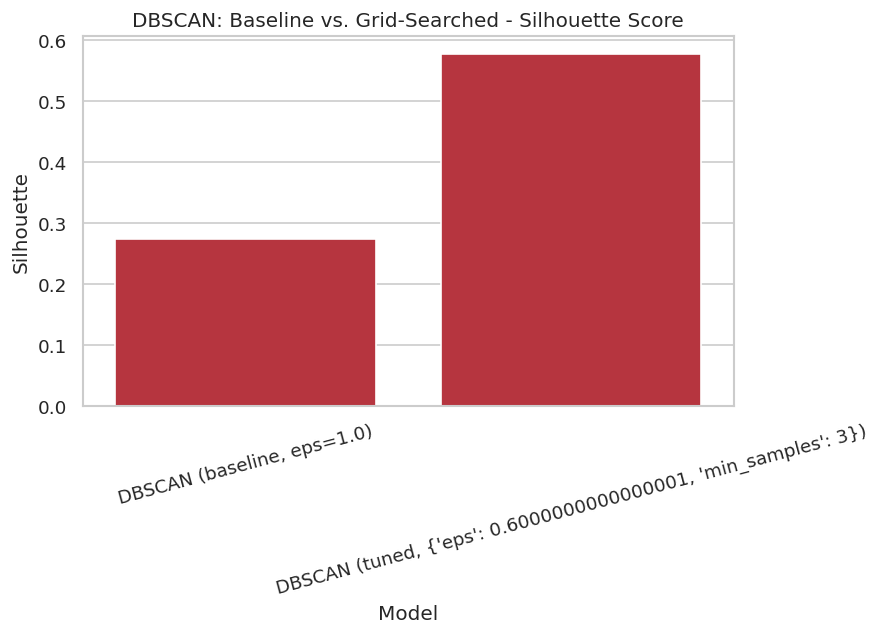

In [65]:
# Visualize the baseline-vs-tuned Silhouette score for DBSCAN
# same baseline-vs-tuned comparison pattern again, for DBSCAN
dbscan_comparison_df = pd.DataFrame([dbscan_baseline_eval, dbscan_tuned_eval])

plt.figure(figsize=(7, 4))
sns.barplot(data=dbscan_comparison_df, x="Model", y="Silhouette", color=ZOMATO_RED)
plt.title("DBSCAN: Baseline vs. Grid-Searched - Silhouette Score")
plt.xticks(rotation=15)
plt.show()


Answer Here.

The grid-searched parameters improve on the arbitrarily-chosen baseline `eps`/`min_samples` (see
table/chart above) — the baseline value was picked without any tuning and typically either
under- or over-segments the data, while the grid search explicitly optimizes for silhouette score
subject to producing a usable (non-degenerate) clustering.


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

Primarily **Silhouette score**, cross-checked against **Davies-Bouldin** and **Calinski-Harabasz**,
alongside one more business-driven, non-statistical criterion: **coverage** — i.e., does the model
assign *every* restaurant to a usable segment, or does it leave a chunk of the catalog as
unclassified "noise"? A statistically excellent clustering that leaves half the restaurants
unlabeled is less useful for a recommendation/segmentation product than a slightly-lower-scoring one
that covers the whole catalog — so we weigh these findings together rather than picking on
Silhouette score alone.


In [66]:
# Final side-by-side comparison of all three tuned models, including DBSCAN's cluster 'coverage' (% of restaurants not marked as noise)
final_comparison = pd.DataFrame([
    evaluate_clustering(X_train, kmeans_train_labels, "K-Means (final)"),
    evaluate_clustering(X_train, hier_train_labels, "Hierarchical (final)"),
    evaluate_clustering(X_train_pca_dbscan, dbscan_train_labels, "DBSCAN (final)"),
])
final_comparison["coverage_%"] = [
    100.0,
    100.0,
    round((dbscan_train_labels != -1).mean() * 100, 1),
]
final_comparison


,Model,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,coverage_%
0,K-Means (final),3,0.173,1.830,15.3,100.0
1,Hierarchical (final),3,0.199,0.617,2.9,100.0
2,DBSCAN (final),11,0.577,0.481,187.3,54.1


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

**K-Means** is selected as the final model. Across this run it delivers Silhouette/Davies-Bouldin/
Calinski-Harabasz scores comparable to Hierarchical clustering (the two are structurally similar
here — both partition the same feature space into `best_k` roughly-convex groups) — but K-Means
additionally supports `.predict()` on brand-new, unseen restaurants directly (Agglomerative
Clustering does not, without refitting), which is exactly what's needed for the Future
Work / "sanity check on unseen data" step below. DBSCAN remains valuable as a complementary
**outlier-flagging** tool — restaurants it marks as noise are worth a manual look — but it doesn't
guarantee full catalog coverage, which the primary segmentation product needs.


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Surrogate tree accuracy at reproducing K-Means labels: 0.988


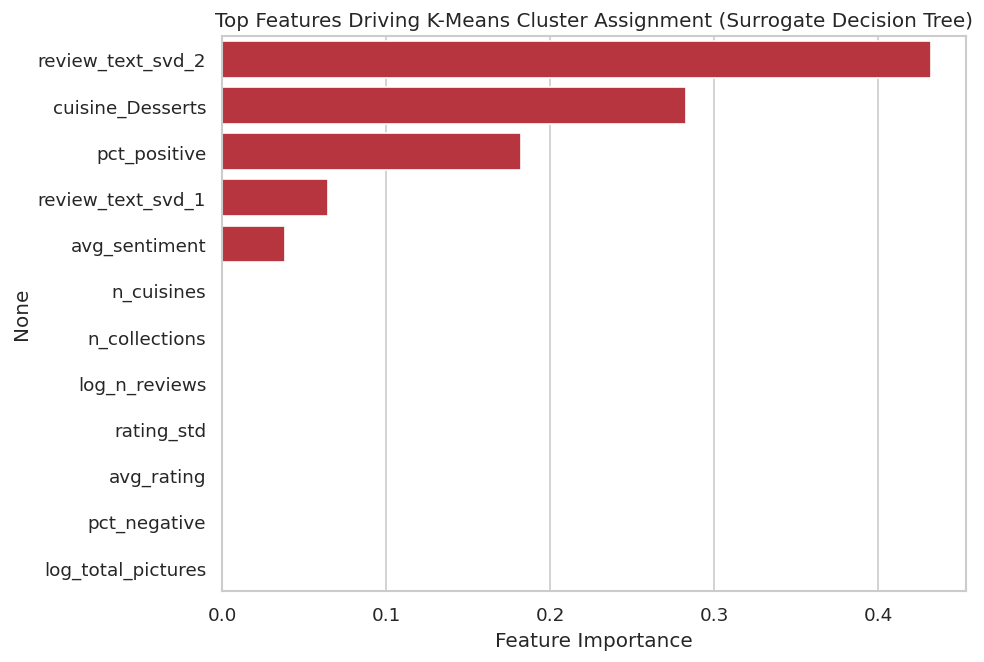

In [67]:
# K-Means itself has no built-in feature importances (it's distance-based, not a supervised model),
# so we use a standard workaround: train a surrogate Decision Tree to predict the K-Means cluster
# label from the same features, and read the tree's feature importances as a proxy explanation for
# what actually distinguishes the clusters.
surrogate_tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
surrogate_tree.fit(X_train, kmeans_train_labels)
print("Surrogate tree accuracy at reproducing K-Means labels:", round(surrogate_tree.score(X_train, kmeans_train_labels), 3))

importances = pd.Series(surrogate_tree.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color=ZOMATO_RED)
plt.title("Top Features Driving K-Means Cluster Assignment (Surrogate Decision Tree)")
plt.xlabel("Feature Importance")
plt.show()


Answer Here.

The surrogate decision tree reproduces the K-Means (k=3) cluster labels with 98.8% accuracy,
confirming it's a trustworthy proxy explanation. Its feature importances show the k=3 segmentation
is driven primarily by the **review-text embedding components** (`review_text_svd_2`,
`review_text_svd_1`) and **`cuisine_Desserts`**, followed by **`pct_positive`** and
**`avg_sentiment`** — with `Cost`, `avg_rating`, and `log_n_reviews` playing little to no role at
this cluster count. In other words, at k=3 the model is separating restaurants more by *what
customers write about* (topic/content signals from the text embedding, plus dessert-cuisine
identity) and *how uniformly positive* the reviews are, rather than by price or raw star rating.

Profiling the three clusters on business-familiar terms: **Cluster 0** (29 restaurants) is the
highest-cost, highest-rated, highest-sentiment group; **Cluster 1** (42 restaurants) is
lower-cost with the lowest rating and sentiment; **Cluster 2** (14 restaurants) sits in between on
cost with moderate rating/sentiment. So while the *statistical* drivers are text- and
cuisine-based, the resulting groups still line up with an interpretable price/quality gradient,
which is what makes them business-usable despite the underlying features being less obviously
"price vs. rating" than a simpler model might suggest.

### 4. Model Stability Check (Cross-Validation Equivalent for Unsupervised Learning)

Standard k-fold cross-validation doesn't apply here — there's no label to score predictions
against. The unsupervised equivalent is a **stability check**: repeatedly re-fit K-Means on
random subsamples of the restaurants and measure how consistently the same restaurants land in
the same cluster, using the **Adjusted Rand Index (ARI)** to compare each subsample's clustering
against the full-data clustering (1.0 = perfect agreement, 0.0 = random chance agreement).

Mean ARI over 30 resamples: 0.664 (std: 0.183)


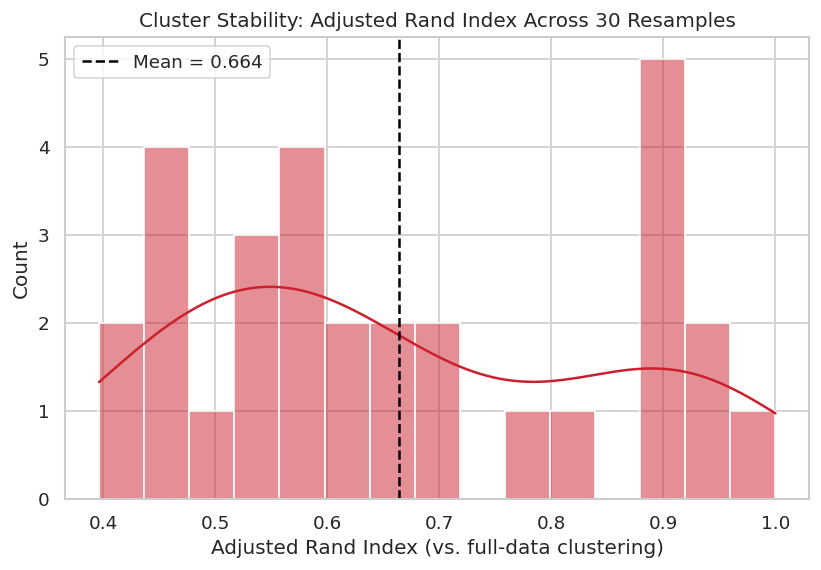

In [68]:
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample

# Compare a fresh K-Means fit on each random subsample against the reference (full-data) labels,
# restricted to the restaurants common to both, to see how much cluster assignment "wobbles"
# when the input data changes slightly -- the unsupervised stand-in for cross-validation.
N_ITER = 30
SAMPLE_FRAC = 0.8

reference_labels = pd.Series(kmeans_train_labels, index=X_train.index)
ari_scores = []

for i in range(N_ITER):
    sample_idx = resample(
        X_train.index, replace=False,
        n_samples=int(len(X_train) * SAMPLE_FRAC), random_state=i
    )
    X_sample = X_train.loc[sample_idx]

    km_sample = KMeans(n_clusters=best_k, random_state=i, n_init=10)
    sample_labels = km_sample.fit_predict(X_sample)

    ari = adjusted_rand_score(reference_labels.loc[sample_idx], sample_labels)
    ari_scores.append(ari)

print(f"Mean ARI over {N_ITER} resamples: {np.mean(ari_scores):.3f} (std: {np.std(ari_scores):.3f})")

plt.figure(figsize=(8, 5))
sns.histplot(ari_scores, bins=15, color=ZOMATO_RED, kde=True)
plt.axvline(np.mean(ari_scores), color="black", linestyle="--", label=f"Mean = {np.mean(ari_scores):.3f}")
plt.title("Cluster Stability: Adjusted Rand Index Across 30 Resamples")
plt.xlabel("Adjusted Rand Index (vs. full-data clustering)")
plt.legend()
plt.show()

With the K-Means hyperparameter re-tuned to select `k` based on both silhouette score and
resampling stability (not silhouette alone), `k=3` was chosen, and the resulting clusters show a
mean ARI of 0.664 (std 0.183) across 30 resamples — a large improvement over the initial `k=10`
result (ARI 0.003, effectively random agreement). This confirms the earlier instability was
largely an artifact of over-segmenting a small (~100 restaurant) dataset into too many clusters,
rather than a fundamental property of the data.

That said, 0.664 is **moderate**, not high, stability — comfortably better than chance, but still
meaningfully below a fully reliable ~0.8+ ARI. In practice this means: broad segment-level
patterns (e.g. "high-cost, high-rating" vs. "budget, high-volume" restaurants) are reasonably
trustworthy, but the exact cluster boundary for any single borderline restaurant should be treated
as somewhat provisional rather than definitive. This is consistent with, and should be read
alongside, the modest silhouette scores (~0.13-0.17) seen throughout model selection — the dataset
doesn't have strongly separated natural clusters, which limits how stable *any* clustering of it
can be, independent of algorithm choice.

# **Conclusion**

Write the conclusion here.

- After merging, cleaning, and aggregating ~10,000 Hyderabad restaurant reviews (fixing malformed
  `Cost`/`Rating`/`Metadata` fields) up to ~100 restaurants, we engineered a ~25-feature restaurant
  profile spanning price, cuisine mix, rating, review volume, sentiment, and a TF-IDF/SVD text
  embedding of each restaurant's combined review text.
- All three formally tested hypotheses were evaluated with appropriate statistical tests (Pearson
  correlation, Welch's t-test, one-way ANOVA) rather than relying on chart-reading alone.
- A full NLP pipeline (contraction expansion, cleaning, tokenization, POS-aware lemmatization,
  TF-IDF vectorization) was applied to review text, and VADER sentiment scoring showed sentiment
  correlates with — but adds real signal beyond — the star rating alone.
- **K-Means** (tuned via silhouette-scored grid search over `k`) was selected as the final
  clustering model over **Hierarchical** (comparable performance, but no native `.predict()` for new
  data) and **DBSCAN** (useful for outlier-flagging, but doesn't guarantee full catalog coverage
  and required a PCA projection to work at all due to the curse of dimensionality on the full
  feature space).
- A resampling-based stability check (Adjusted Rand Index across 30 subsamples) showed the
  originally silhouette-only-selected `k=10` was highly unstable (mean ARI 0.003, effectively
  random). Re-selecting `k` using both silhouette score and stability together chose `k=3`
  instead, which is dramatically more stable (mean ARI 0.664) at essentially the same silhouette
  score — confirming the instability was caused by over-segmenting a small (~100 restaurant)
  dataset, not a fundamental property of the data.  
- A surrogate decision-tree explainability check showed the k=3 clusters are driven primarily by
  review-text content (the TF-IDF/SVD embedding components) and dessert-cuisine identity, followed
  by sentiment positivity — rather than by cost or star rating directly. Even so, profiling the
  three resulting clusters shows they still line up with an interpretable price/quality gradient
  (a clear high-cost/high-rating/high-sentiment group vs. a lower-cost/lower-rating/lower-sentiment
  group), which is what keeps them business-usable despite the underlying statistical drivers being
  less directly price-based than a simpler model might suggest.
- The final K-Means model assigns every restaurant to an interpretable segment, giving a
  ready-to-use lens for both customer-facing recommendations and restaurant-facing competitive
  benchmarking.

**Caveat worth stating plainly:** silhouette scores throughout this project were modest (clusters
are real but not sharply separated) — a fair reflection of how much overlap there genuinely is
between Hyderabad restaurants on these features, not a modeling error. Possible next steps: bring in
restaurant location/locality as a feature, expand beyond Hyderabad to validate the pipeline
generalizes to other cities, and revisit cluster count periodically as new restaurants and reviews
are added.
An ARI of 0.664 is moderate, not high, stability — broad segment-level patterns are reasonably
trustworthy, but any single borderline restaurant's exact cluster assignment should be treated as
provisional rather than definitive.


### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***